In [3]:
import sys
import os 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

sys.path.append(os.path.abspath("../"))
from simulators.CA_modified import CellularAutomaton_modfied


In [4]:
def height_update(delta_h: float) -> float:
    if delta_h > 0:
        return 1.2
    elif delta_h < 0:
        return 0.8
    return 1.0

In [5]:
# Parameters, no wind, no height effect
N = 100
wind = np.ones((N, N))
heights = np.zeros((N, N))

start_point = [(N // 2, N // 2)]
start_state = [0.6]

steps = 60
display_every = 5


# Impact of the age map on the spread of fire with Peterson’s flammability

In [6]:
# Different ages configurations

def uniform_age(N, age):
    return age * np.ones((N, N))


def central_young_patch(N, background_age=30, patch_age=5, patch_size=24):
    age = background_age * np.ones((N, N))
    c = N // 2
    h = patch_size // 2
    age[c-h:c+h, c-h:c+h] = patch_age
    return age


def central_old_patch(N, background_age=5, patch_age=30, patch_size=24):
    age = background_age * np.ones((N, N))
    c = N // 2
    h = patch_size // 2
    age[c-h:c+h, c-h:c+h] = patch_age
    return age


def horizontal_gradient(N, age_min=0, age_max=40):
    return np.tile(np.linspace(age_min, age_max, N), (N, 1))


def random_patches(N, low=5, high=35, block=10, seed=0):
    rng = np.random.default_rng(seed)
    coarse = rng.uniform(low, high, size=(N // block + 1, N // block + 1))
    age = np.kron(coarse, np.ones((block, block)))
    return age[:N, :N]


age_configs = {
    "Uniform young": uniform_age(N, 5),
    "Uniform old": uniform_age(N, 30),
    "Young patch center": central_young_patch(N),
    "Old patch center": central_old_patch(N),
    "Horizontal gradient": horizontal_gradient(N),
    "Random patches": random_patches(N),
}

In [7]:
def run_simulation(age_grid, steps=60, display_every=5,
                   t_max=30.0, p_max=1.0, alpha_age=2.0):
    CA = CellularAutomaton_modfied(
        grid_height=N,
        grid_width=N,
        wind_grid=wind,
        height_grid=heights,
        age_grid=age_grid,
        phi=height_update,
        t_max=t_max,
        p_max=p_max,
        alpha_age=alpha_age,
    )

    CA.initialize_ignition(start_point, start_state)

    snapshots = []

    for step in range(steps + 1):
        if step % display_every == 0:
            snapshots.append((step, CA.get_state().copy()))
        if step < steps:
            CA.evolve()

    return snapshots

In [8]:
def plot_age_and_fire(
    name,
    age_grid,
    steps=60,
    display_every=5,
    t_max=30.0,
    p_max=1.0,
    alpha_age=2.0,
):
    snapshots = run_simulation(
        age_grid,
        steps=steps,
        display_every=display_every,
        t_max=t_max,
        p_max=p_max,
        alpha_age=alpha_age,
    )

    #  age maps
    fig_age, ax_age = plt.subplots(figsize=(5, 5))
    im_age = ax_age.imshow(age_grid, cmap="YlGn", origin="lower")
    ax_age.set_title(f"{name} - age map")
    ax_age.set_xticks([])
    ax_age.set_yticks([])
    cbar_age = fig_age.colorbar(im_age, ax=ax_age, fraction=0.046, pad=0.04)
    cbar_age.set_label("Age")
    plt.show()

    # fire maps
    n_snaps = len(snapshots)
    ncols = 4
    nrows = int(np.ceil(n_snaps / ncols))

    fig_fire, axes = plt.subplots(
        nrows, ncols,
        figsize=(4 * ncols, 4 * nrows),
        constrained_layout=True
    )

    axes = np.array(axes).reshape(-1)

    for ax, (step, state) in zip(axes, snapshots):
        im_fire = ax.imshow(state, vmin=0, vmax=1, cmap="magma", origin="lower")
        ax.set_title(f"Step {step}")
        ax.set_xticks([])
        ax.set_yticks([])

    for ax in axes[len(snapshots):]:
        ax.axis("off")

    cbar_fire = fig_fire.colorbar(
        im_fire,
        ax=axes.tolist(),
        fraction=0.02,
        pad=0.02
    )
    cbar_fire.set_label("Fire Intensity")

    fig_fire.suptitle(f"{name} - Fire Propagation", fontsize=14)
    plt.show()

# Visualisation

## With $\alpha = 2$ in the Peterson function

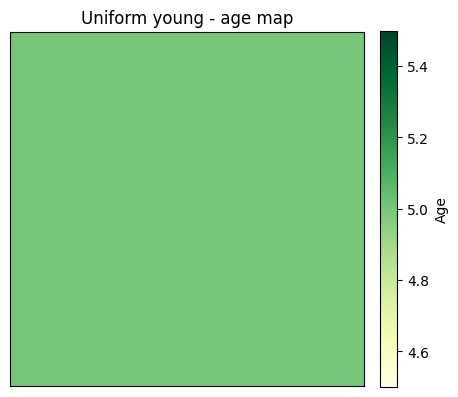

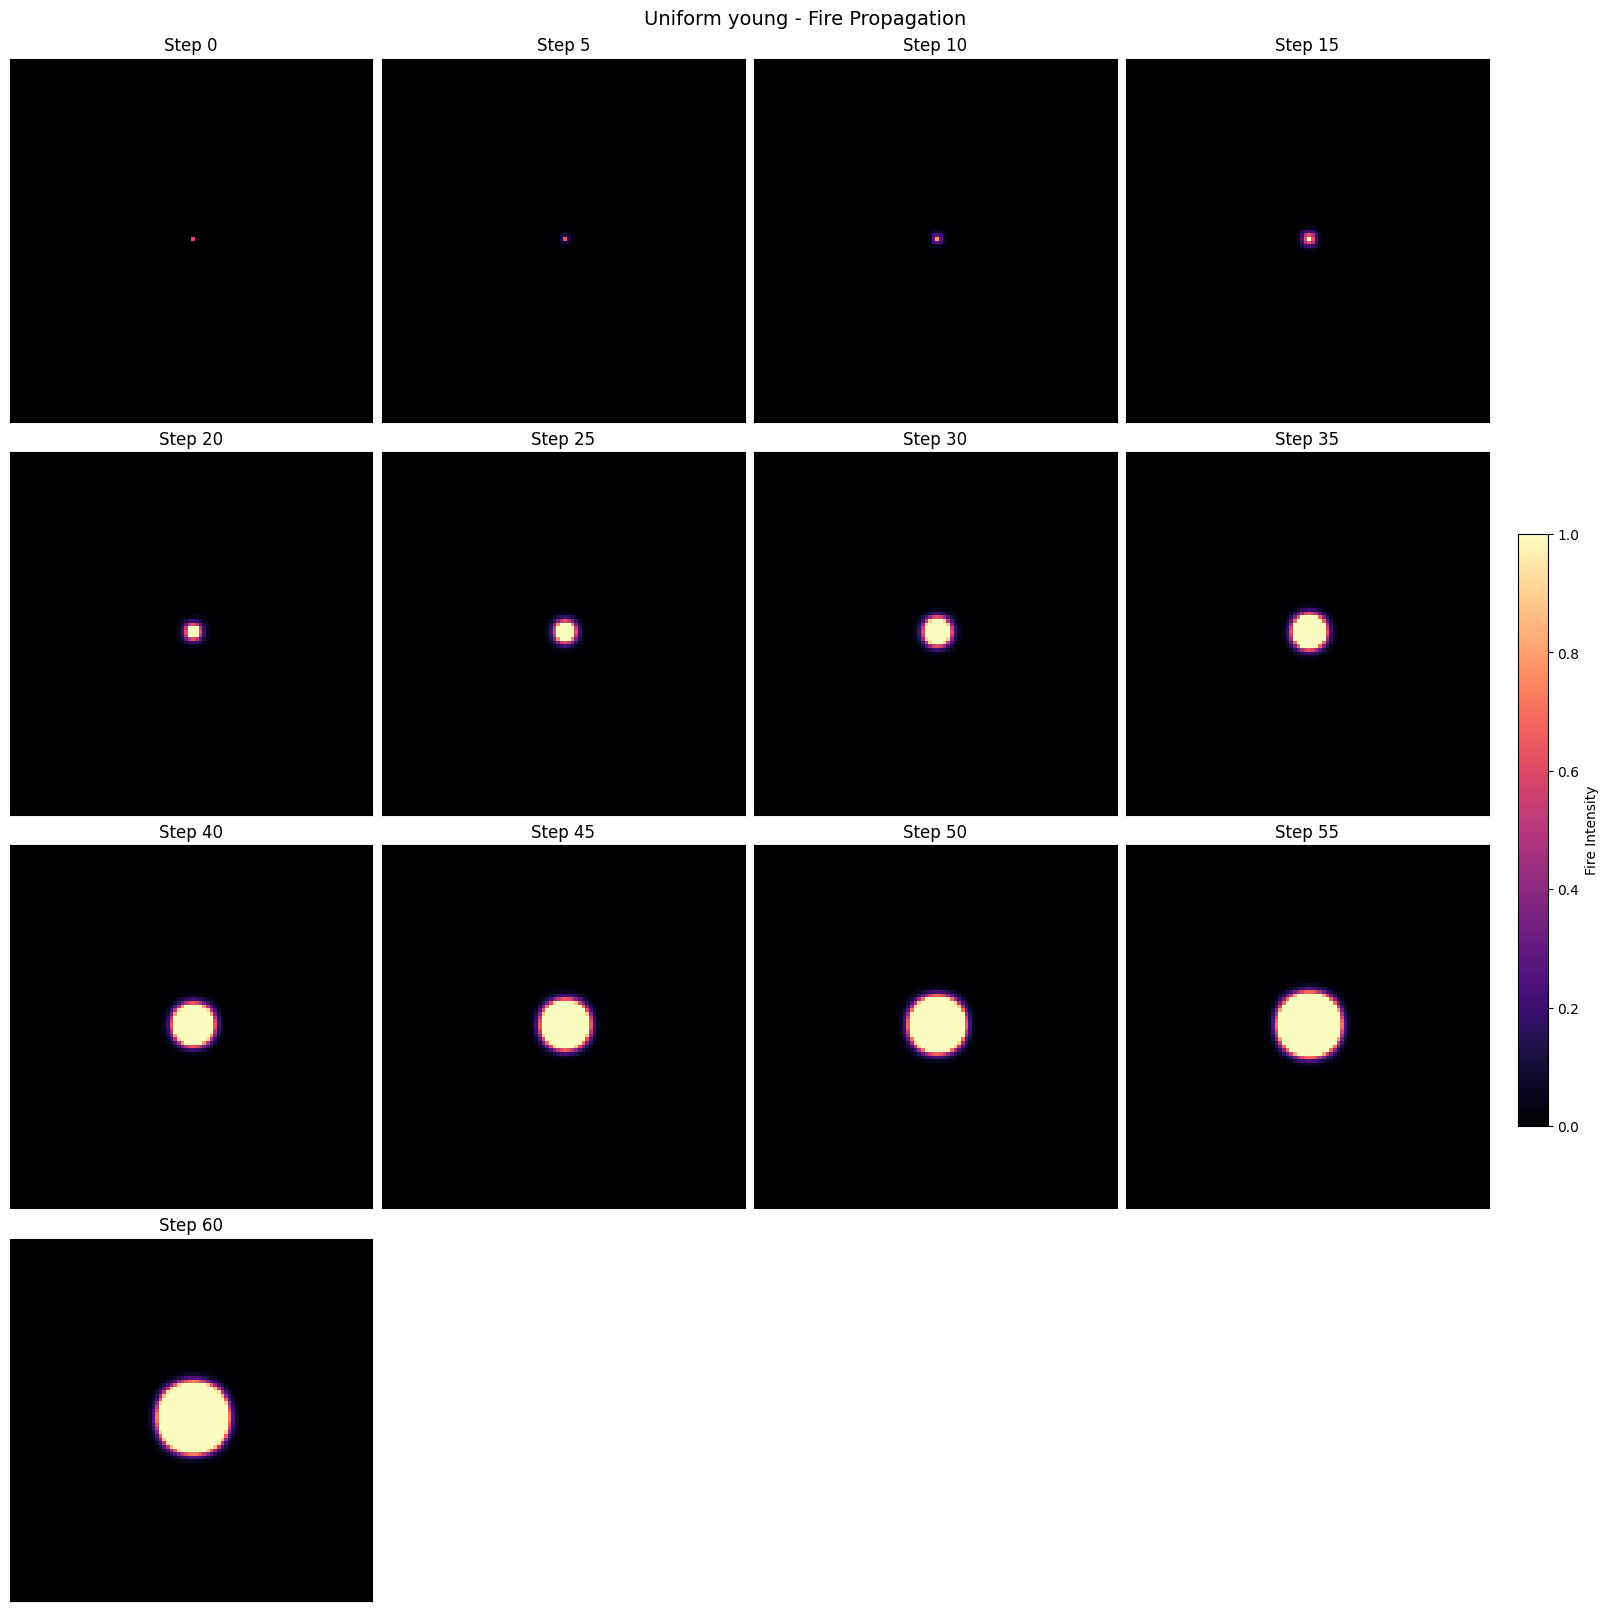

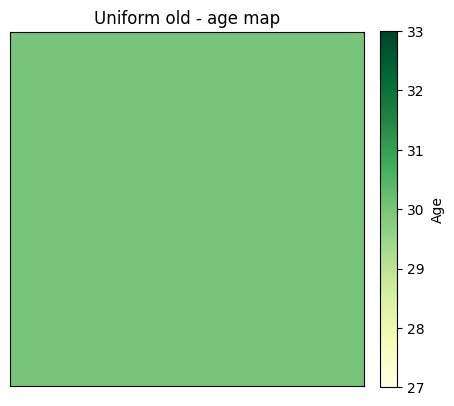

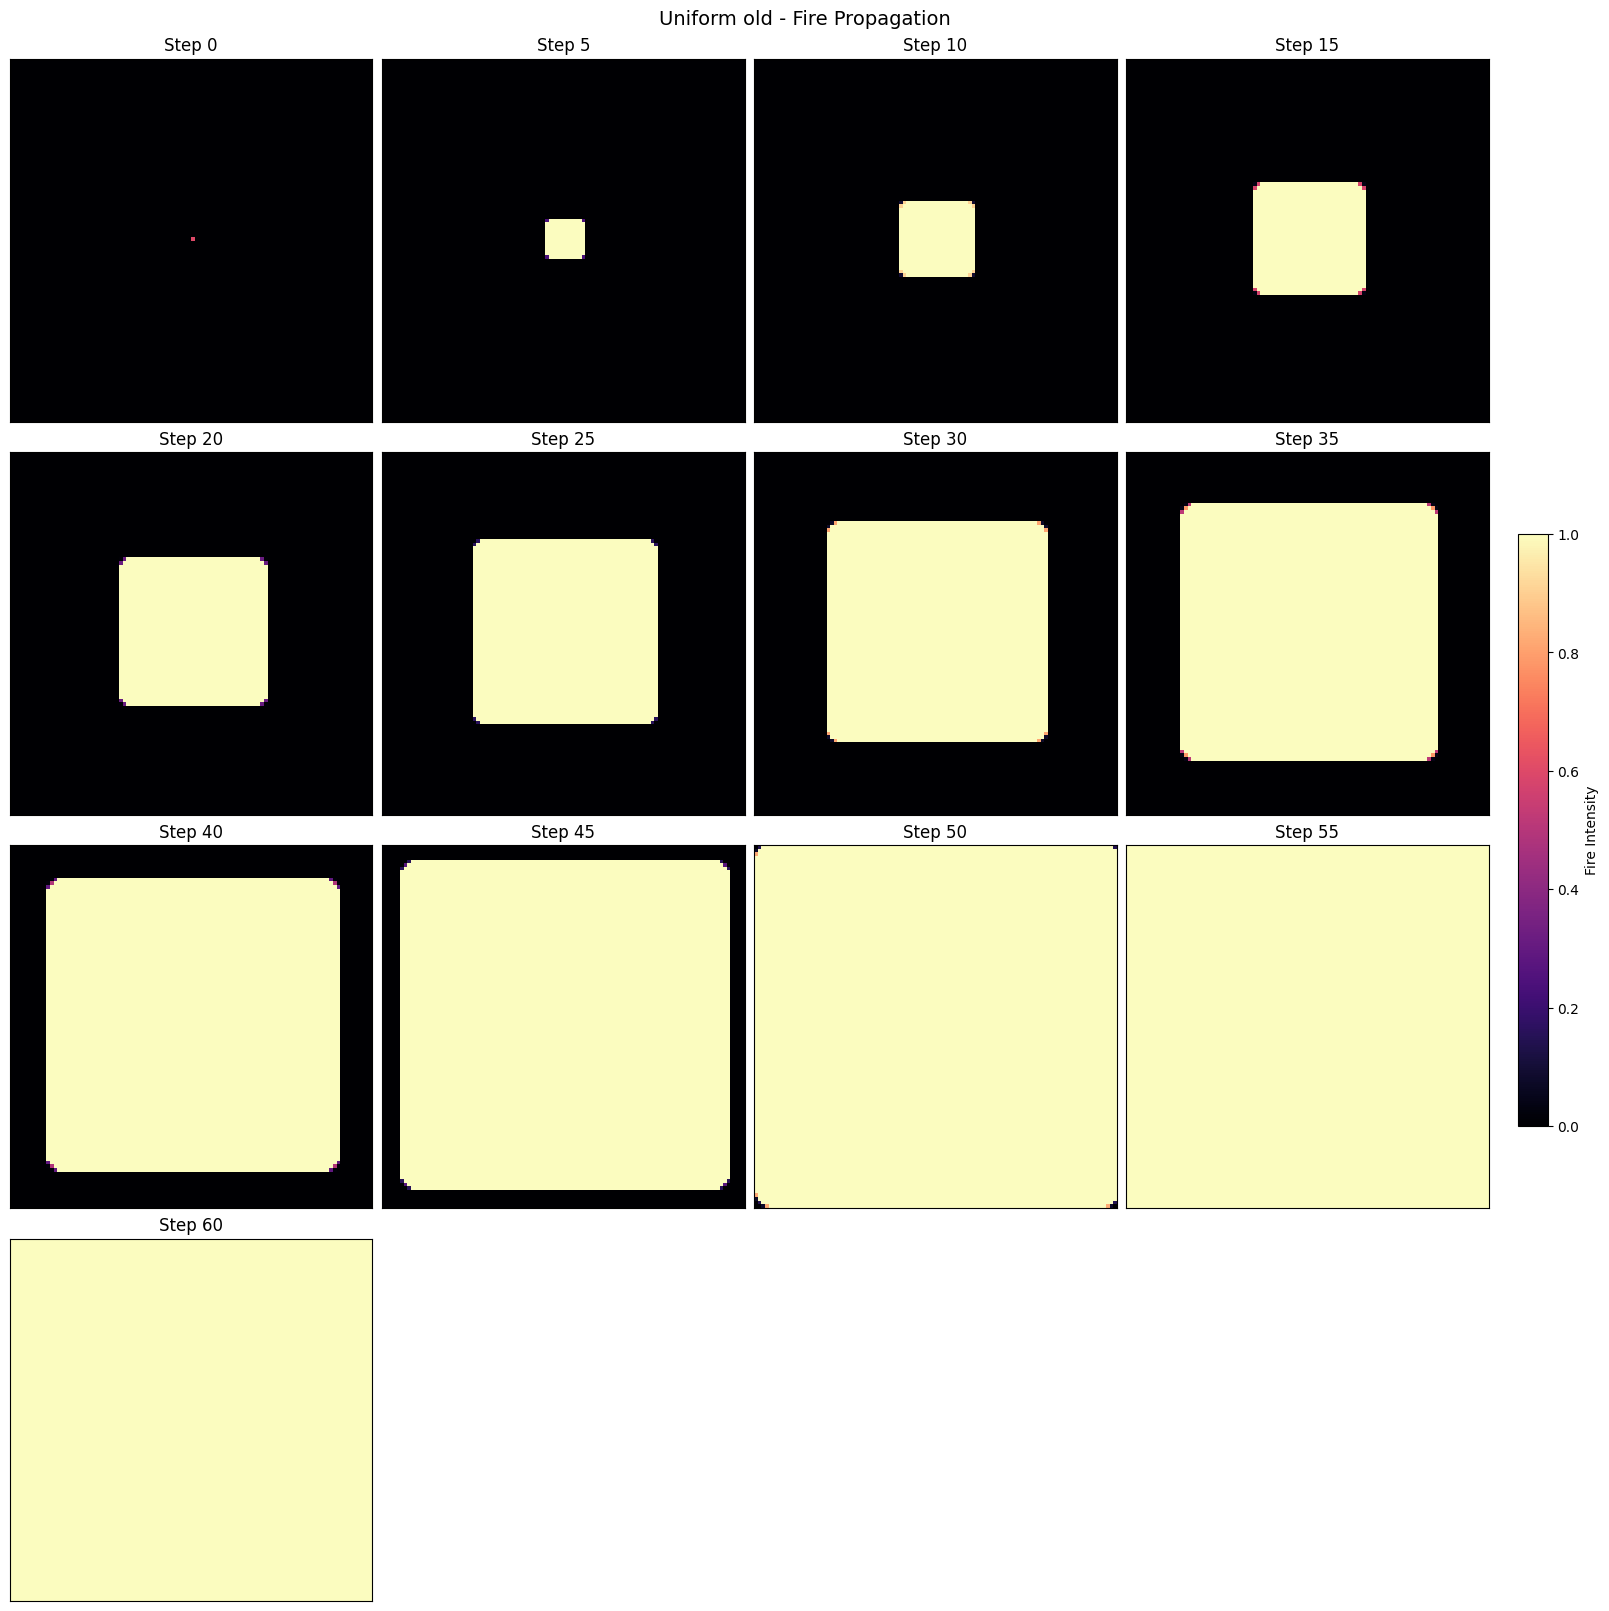

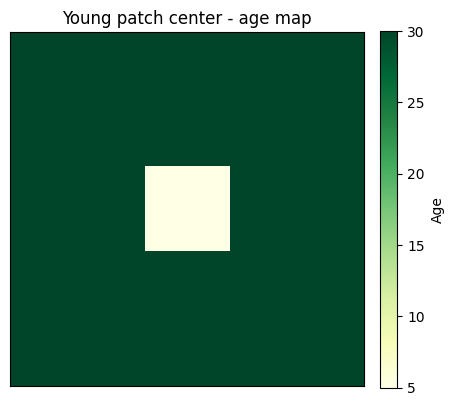

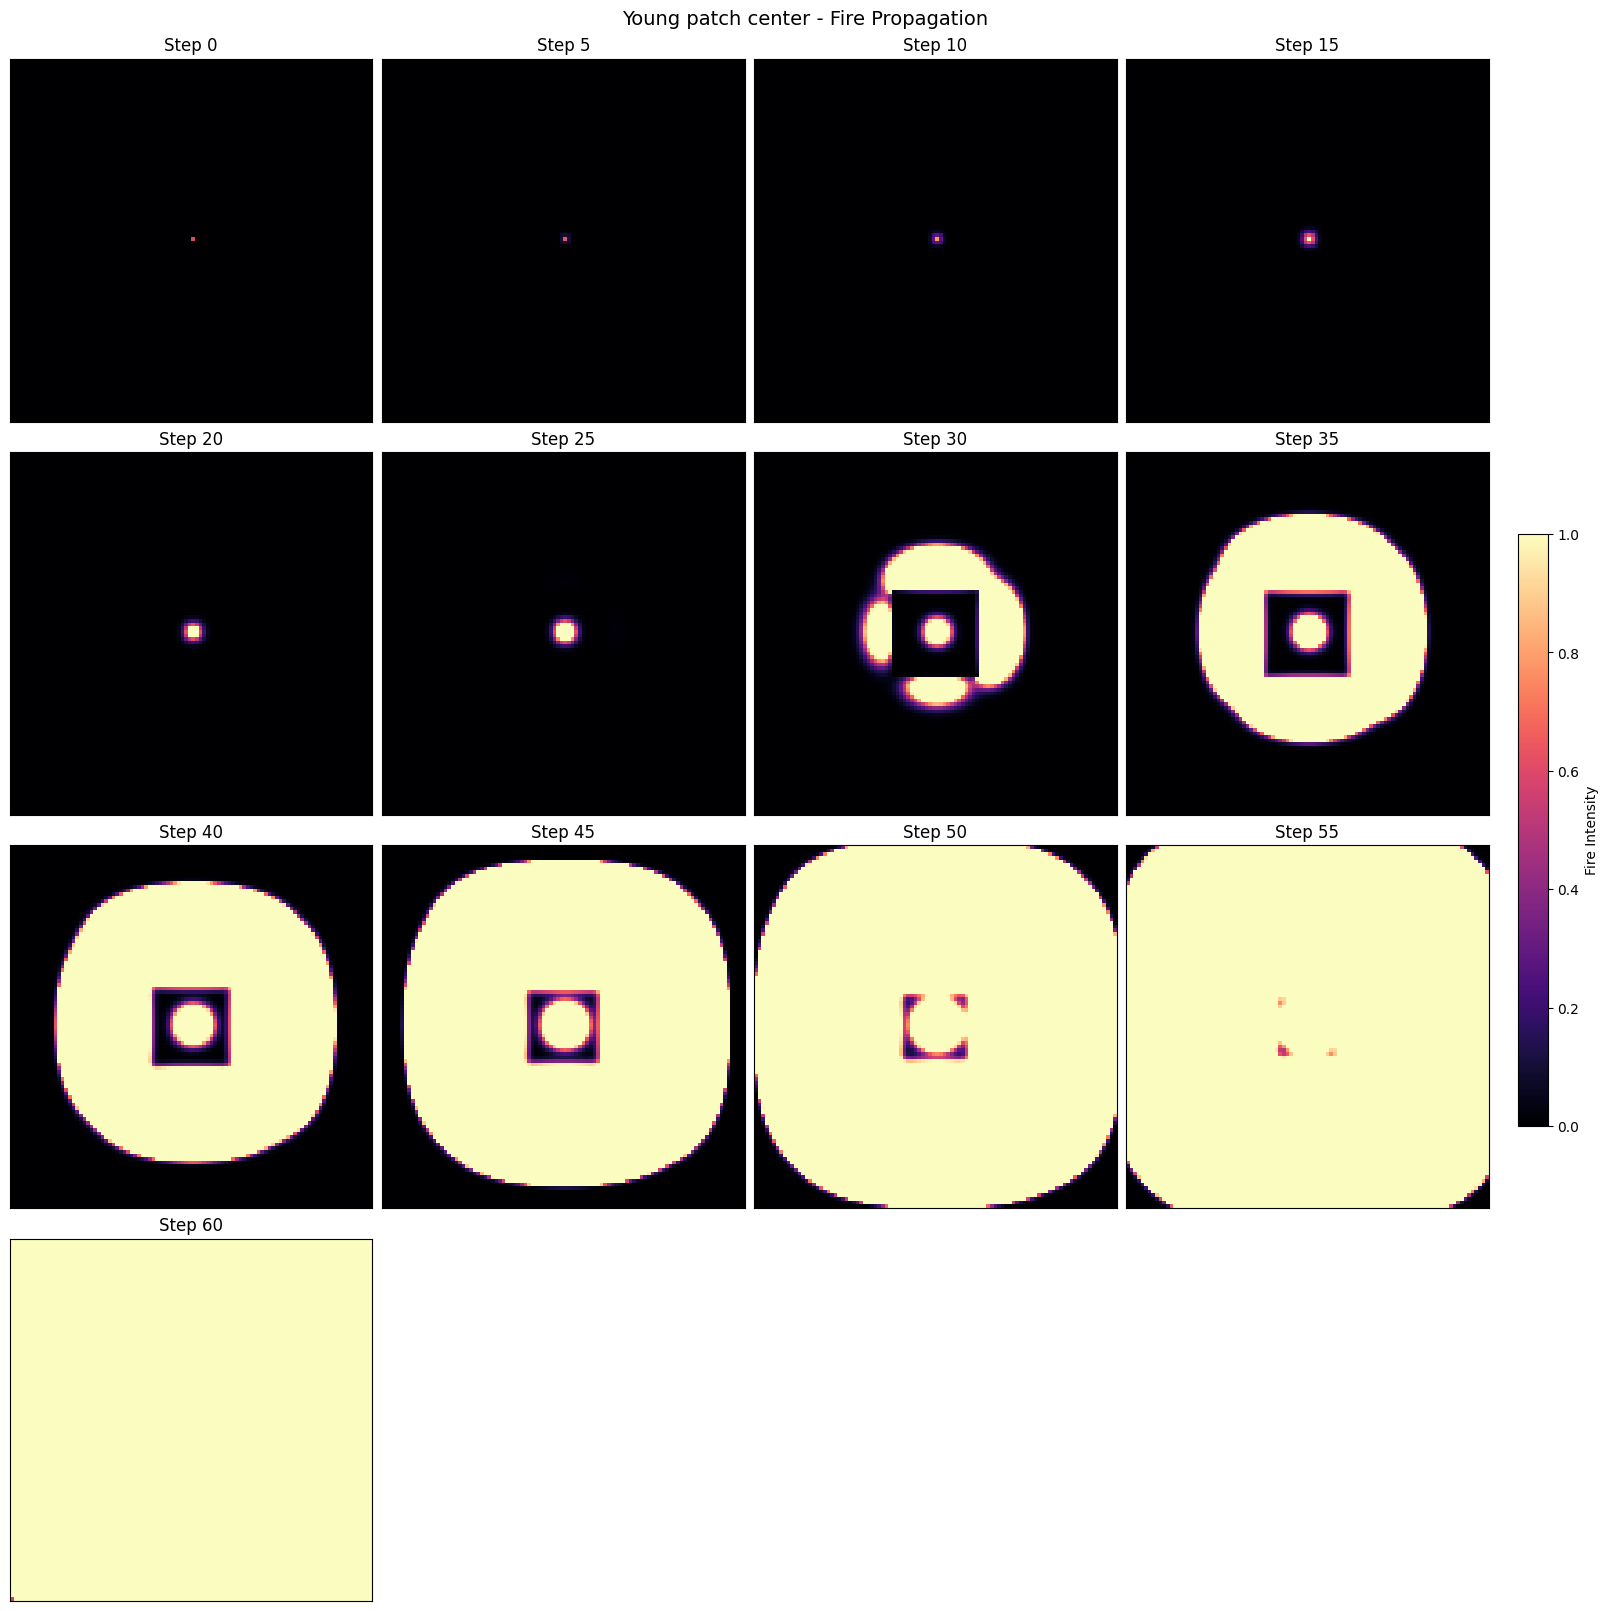

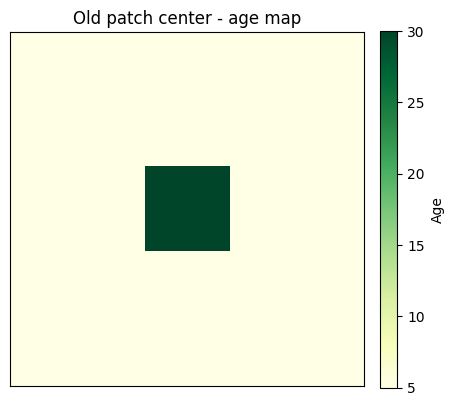

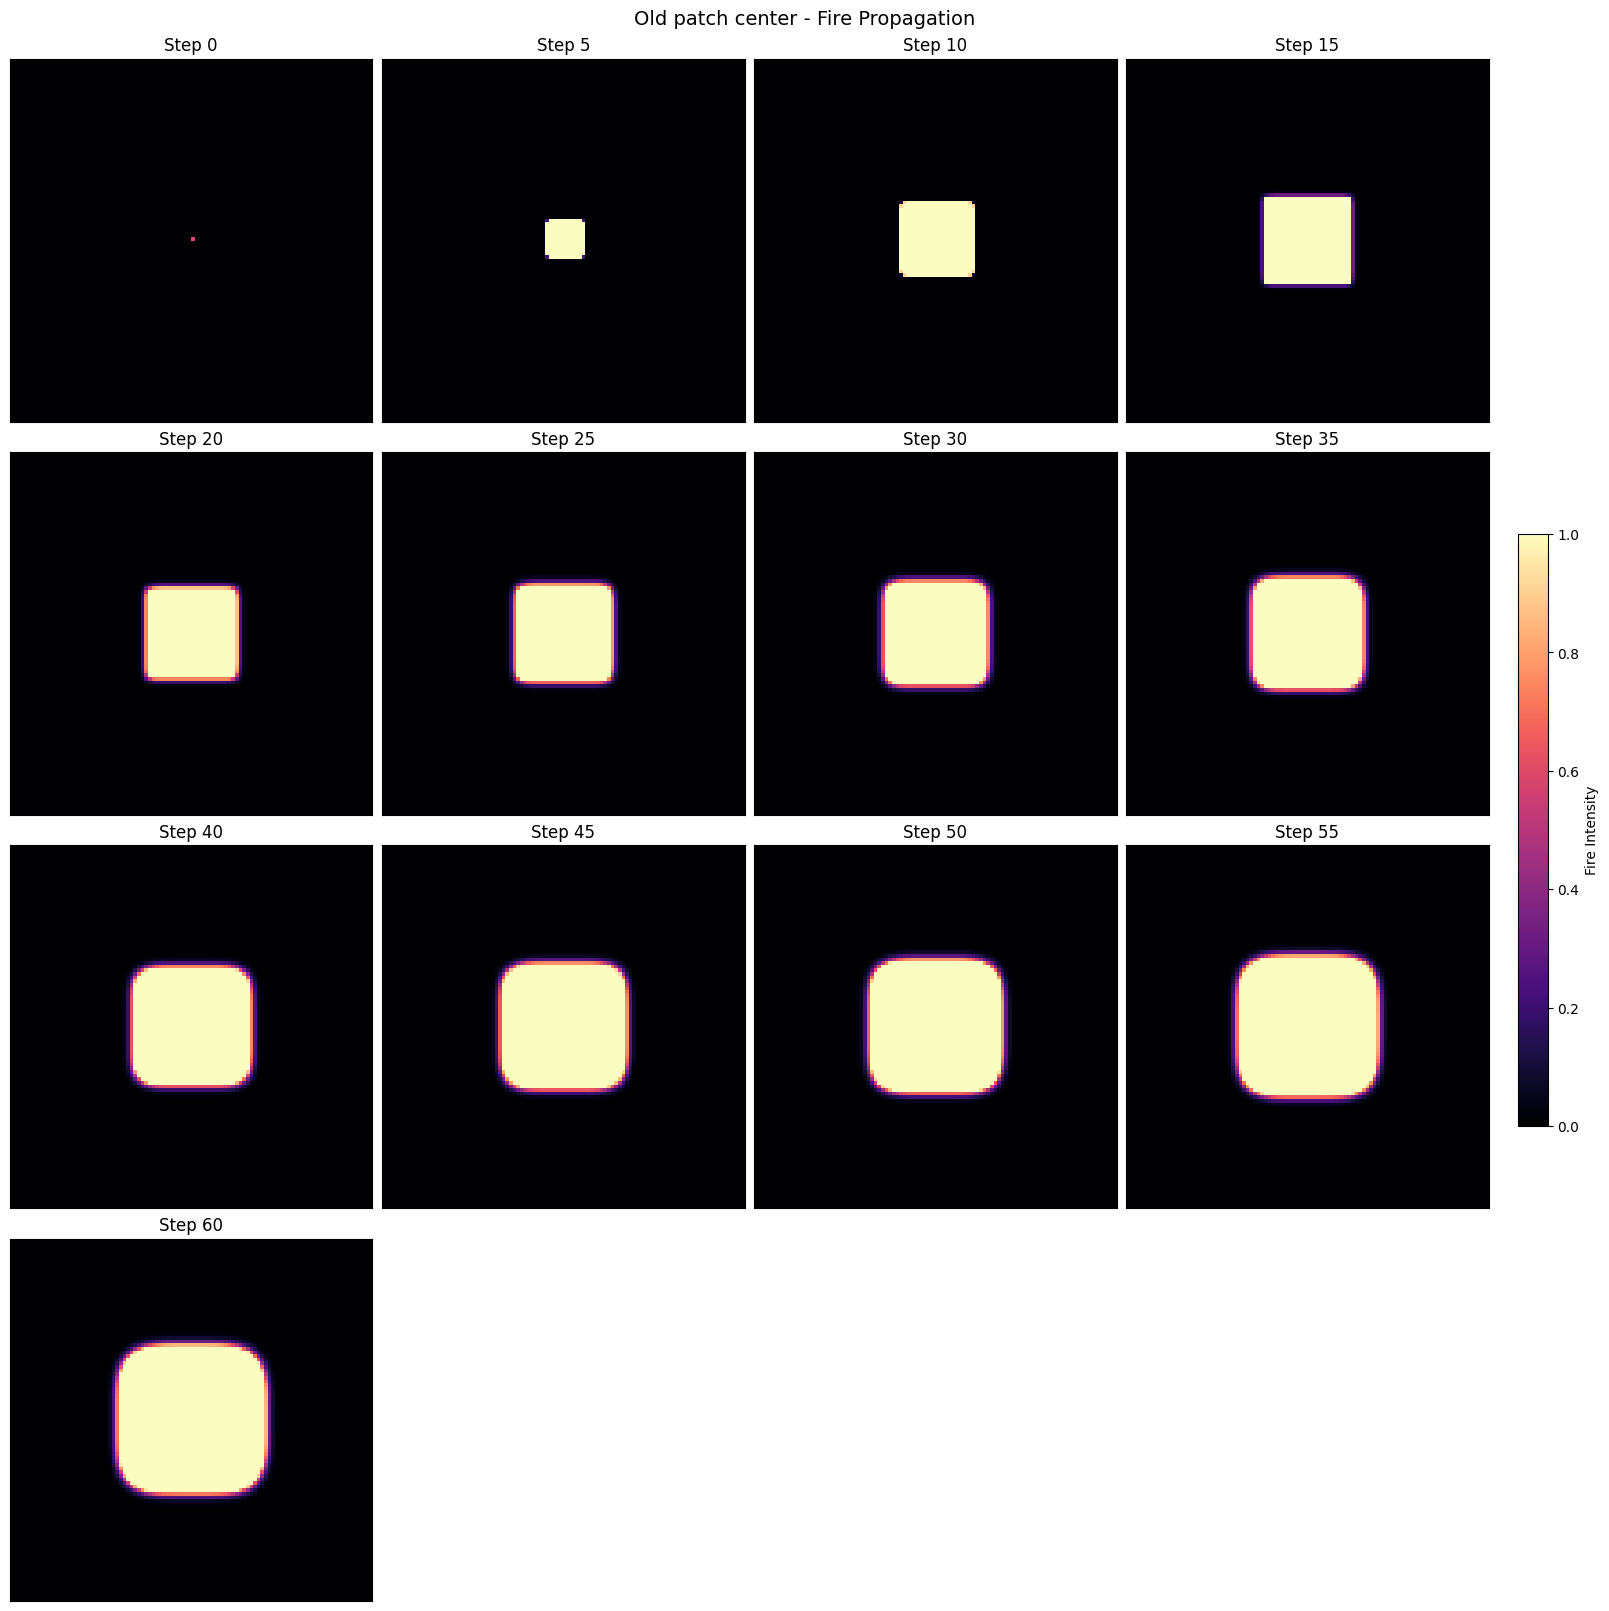

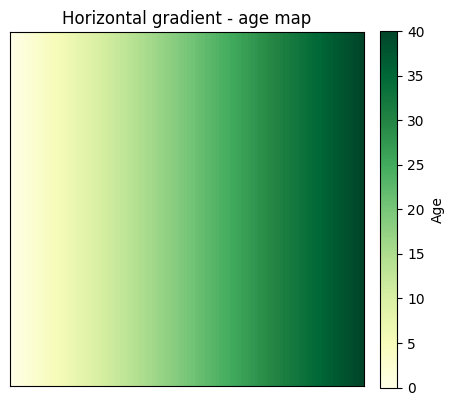

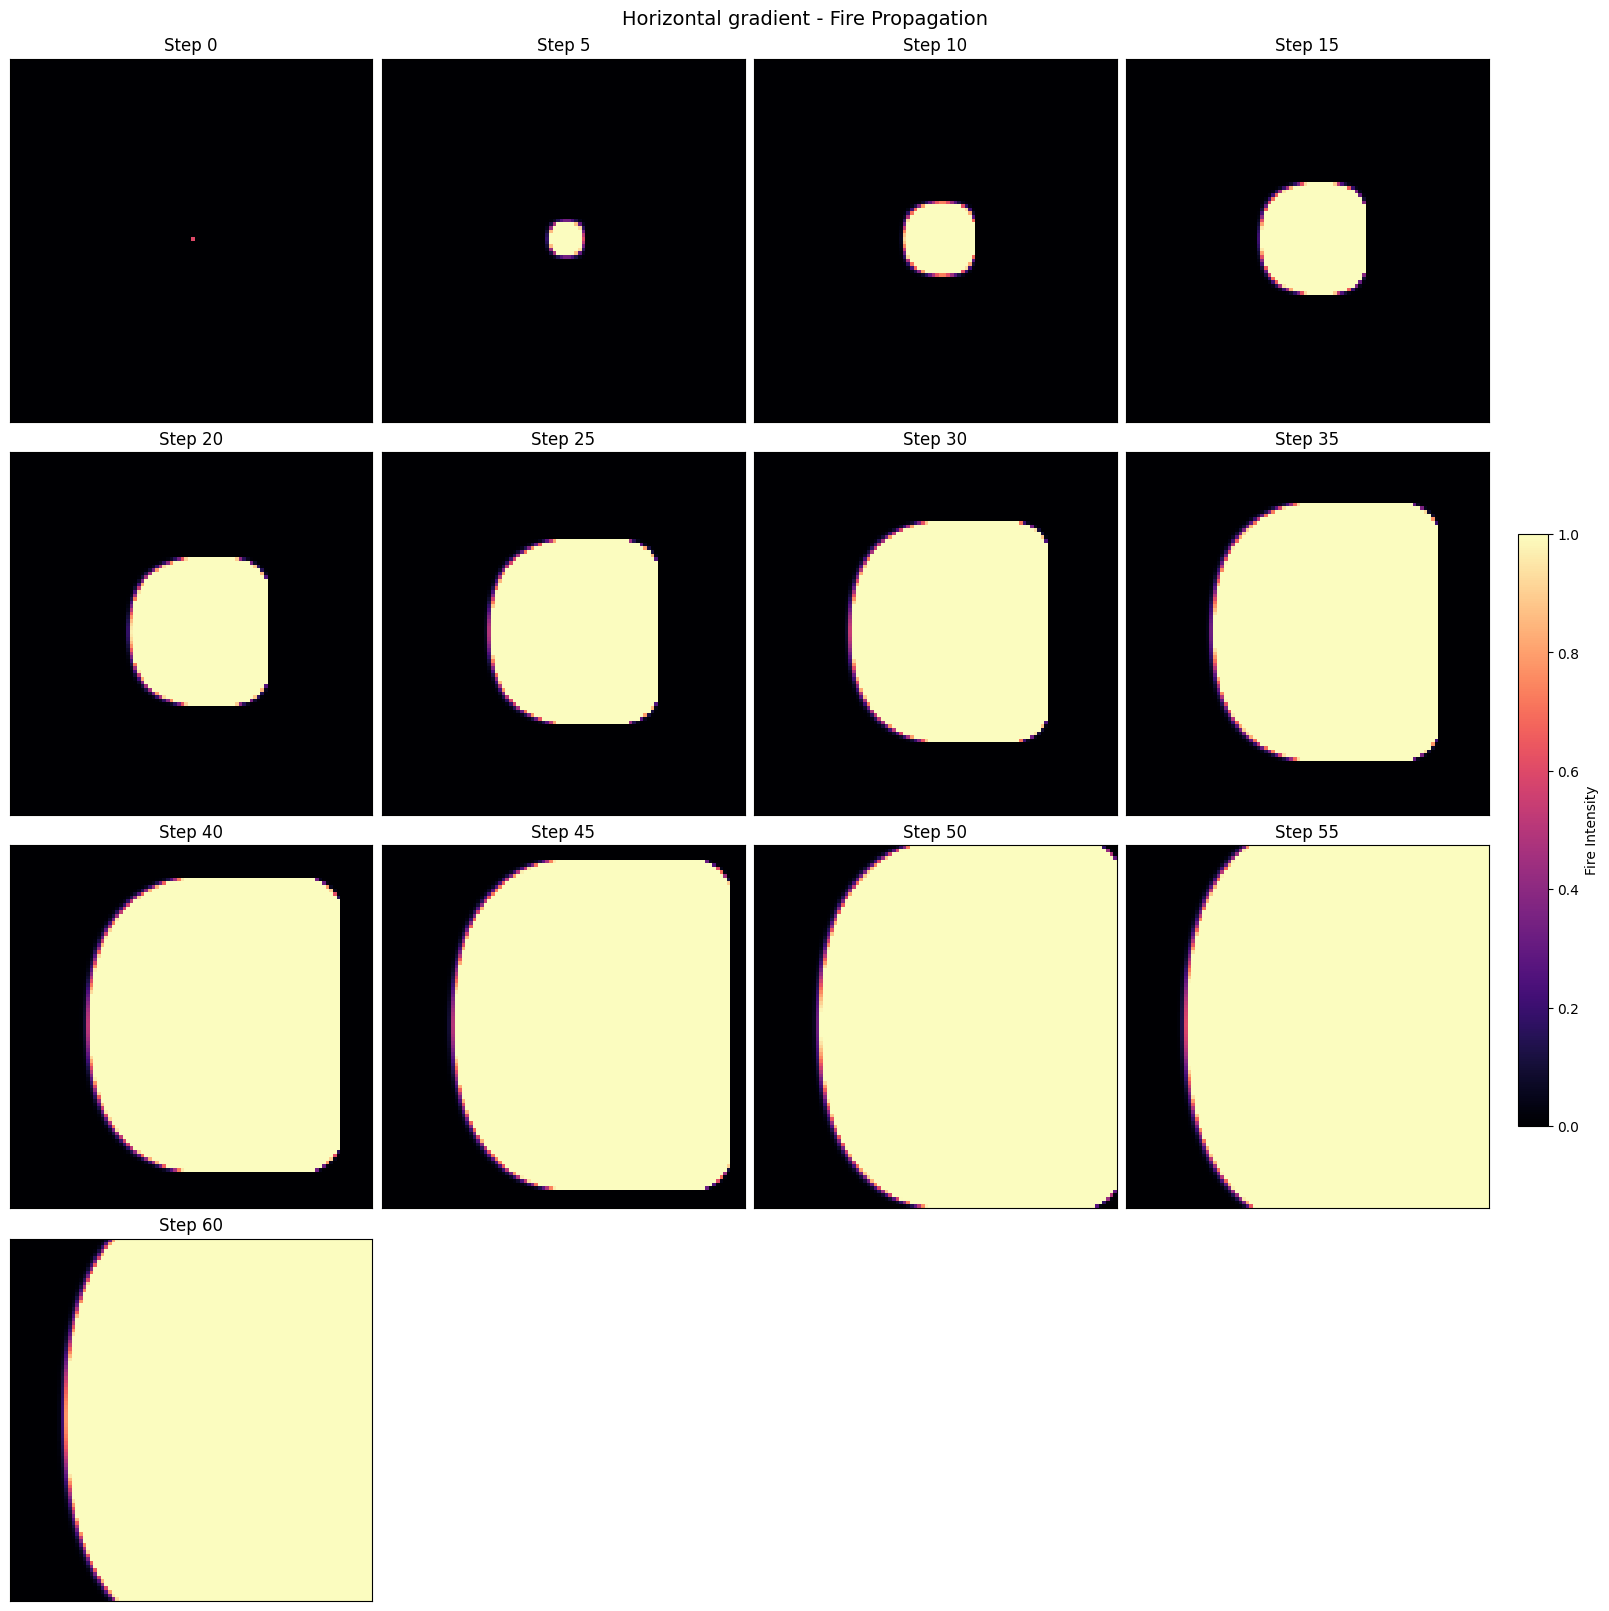

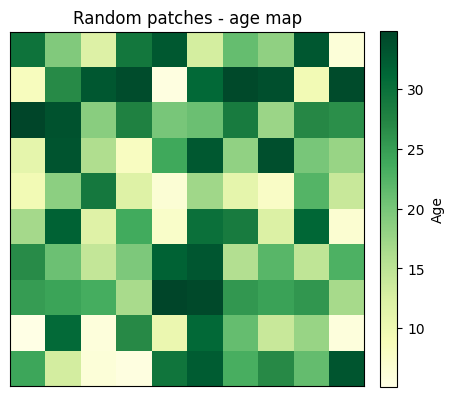

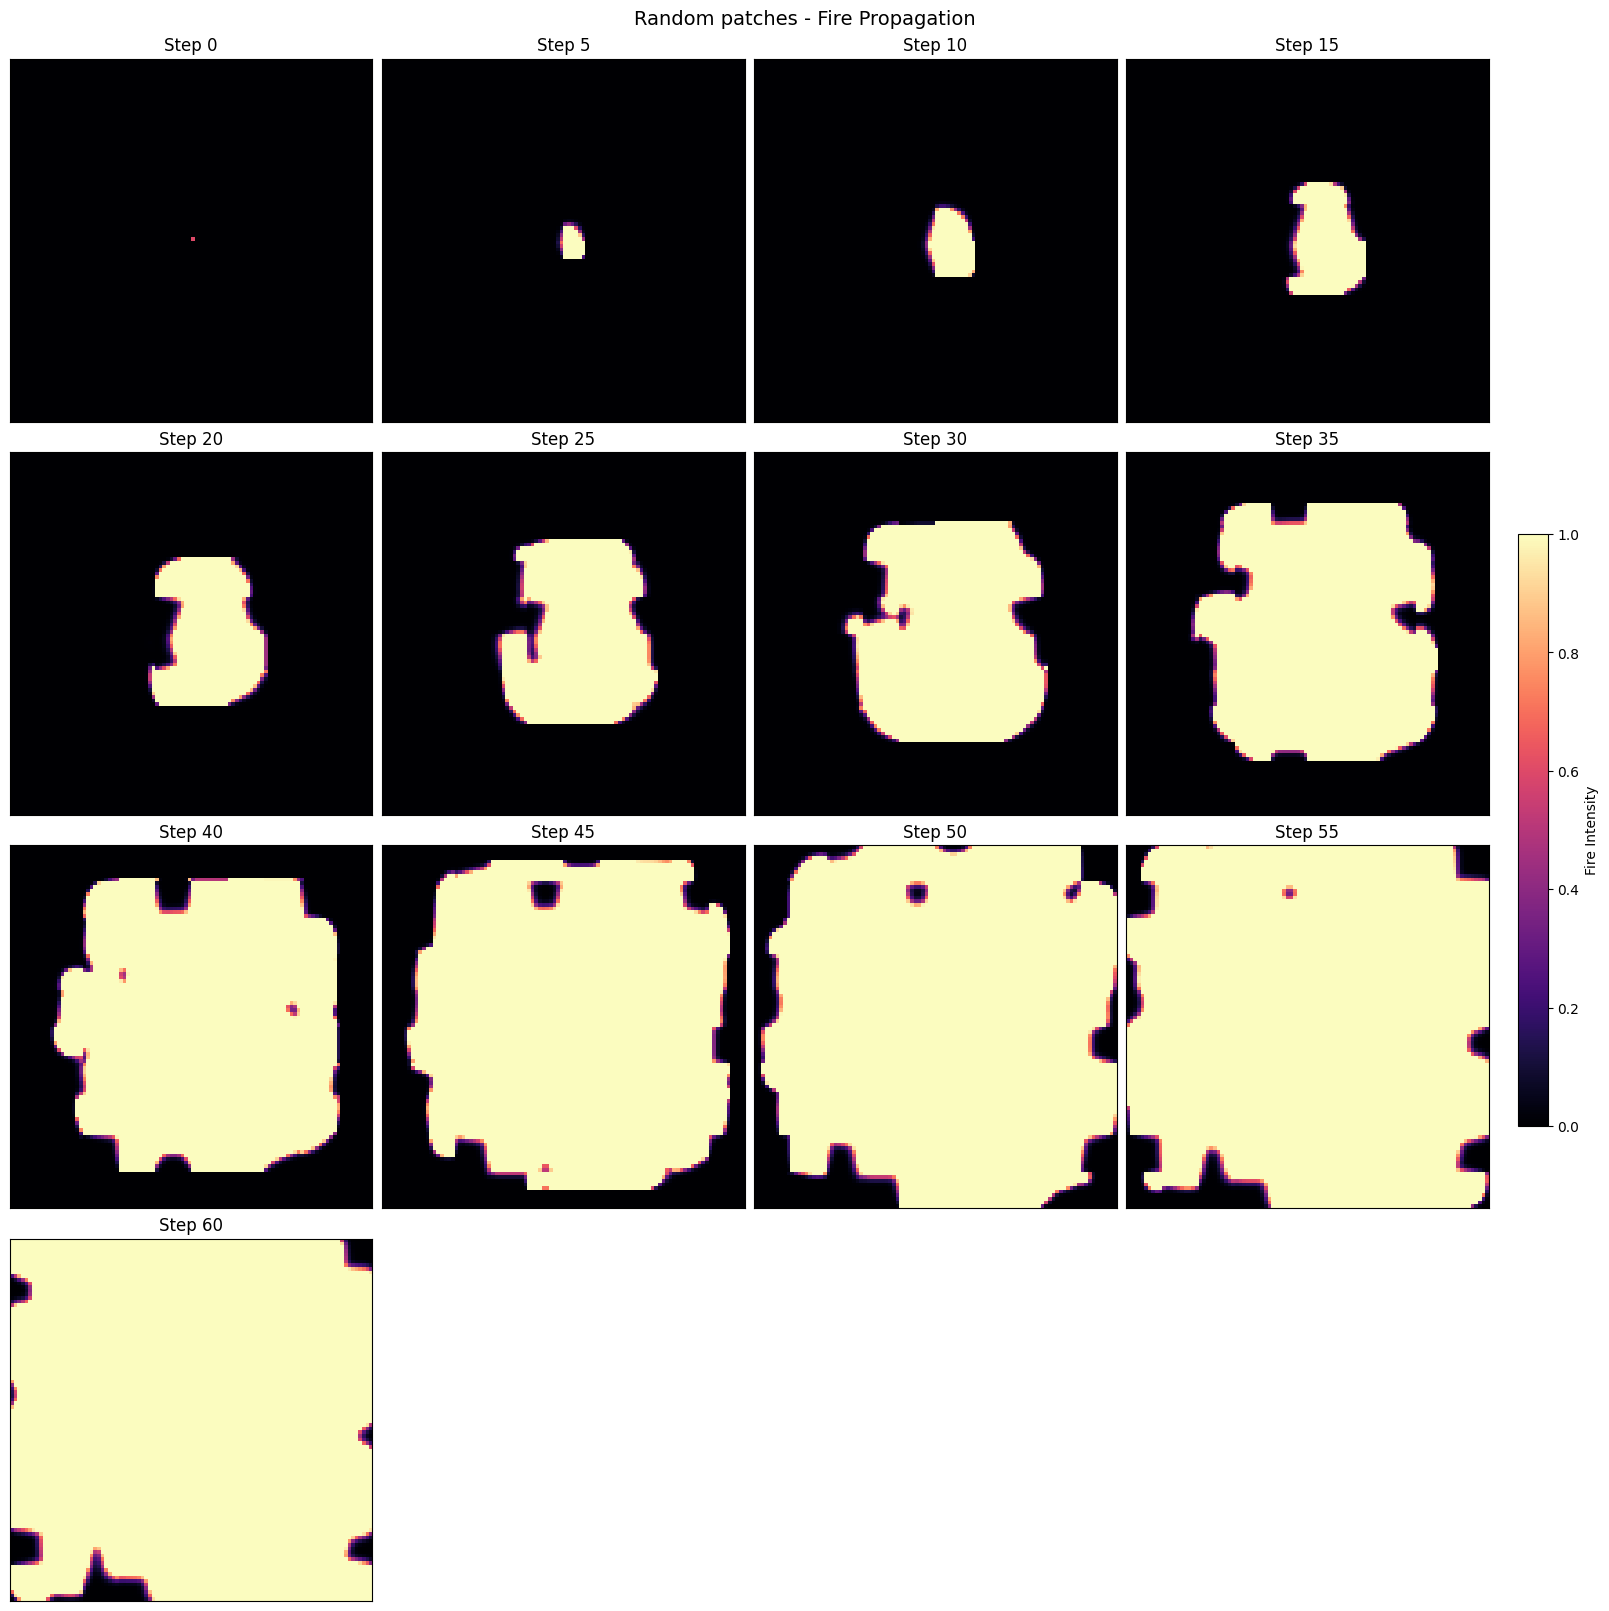

In [9]:
for name, age_grid in age_configs.items():
    plot_age_and_fire(
        name,
        age_grid,
        steps=60,
        display_every=5,
        t_max=30.0,
        p_max=1.0,
        alpha_age=2.0,
    )

# Area burned over time in function of the models

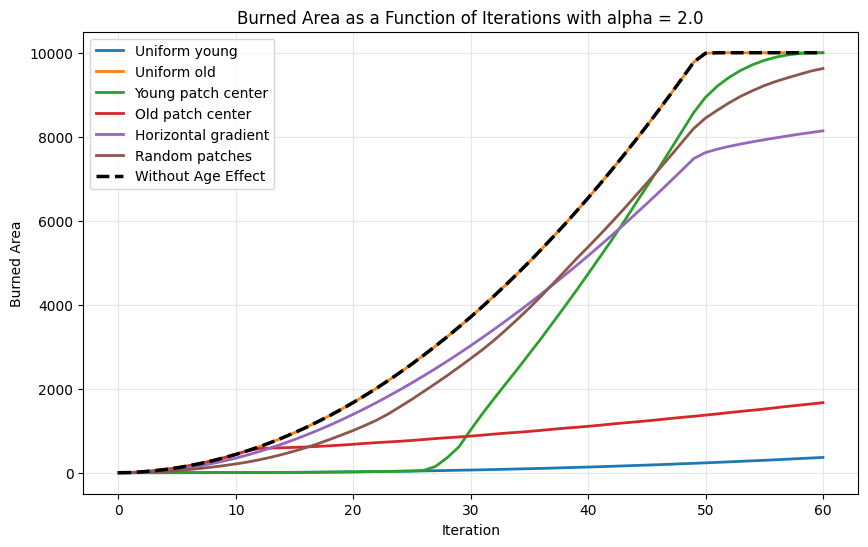

In [18]:
# Parameters, no wind, no height effect
N = 100
wind = np.ones((N, N))
heights = np.zeros((N, N))

start_point = [(N // 2, N // 2)]
start_state = [0.6]

steps = 60


def height_update(delta_h: float) -> float:
    if delta_h > 0:
        return 1.2
    elif delta_h < 0:
        return 0.8
    return 1.0



#  Burned area
def burned_area(state_grid: np.ndarray) -> float:
    return np.sum(state_grid)



def run_burned_area_curve(
    age_grid,
    use_age=True,
    steps=60,
    t_max=30.0,
    p_max=1.0,
    alpha_age=2.0,
):
    """
 Return the burned area at each iteration. If use_age=False, we neutralize the effect of age
 by giving all cells a max inflammability.
    """
    if use_age:
        effective_age_grid = age_grid.copy()
        effective_t_max = t_max
        effective_p_max = p_max
        effective_alpha_age = alpha_age
    else:
        effective_age_grid = 1000.0 * np.ones_like(age_grid)
        effective_t_max = 1.0
        effective_p_max = 1.0
        effective_alpha_age = 1.0

    CA = CellularAutomaton_modfied(
        grid_height=N,
        grid_width=N,
        wind_grid=wind,
        height_grid=heights,
        age_grid=effective_age_grid,
        phi=height_update,
        t_max=effective_t_max,
        p_max=effective_p_max,
        alpha_age=effective_alpha_age,
    )

    CA.initialize_ignition(start_point, start_state)

    areas = [burned_area(CA.get_state())]

    for _ in range(steps):
        CA.evolve()
        areas.append(burned_area(CA.get_state()))

    return np.arange(steps + 1), np.array(areas)

plt.figure(figsize=(10, 6))

for name, age_grid in age_configs.items():
    t, area = run_burned_area_curve(
        age_grid,
        use_age=True,
        steps=steps,
        t_max=30.0,
        p_max=1.0,
        alpha_age=2.0,
    )
    plt.plot(t, area, linewidth=2, label=name)

# Adding a reference curve without age effect
reference_age = next(iter(age_configs.values()))
t_ref, area_ref = run_burned_area_curve(
    reference_age,
    use_age=False,
    steps=steps,
)
plt.plot(
    t_ref,
    area_ref,
    "k--",
    linewidth=2.5,
    label="Without Age Effect"
)

plt.xlabel("Iteration")
plt.ylabel("Burned Area")
plt.title("Burned Area as a Function of Iterations with alpha = 2.0")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# With $\alpha = 1$

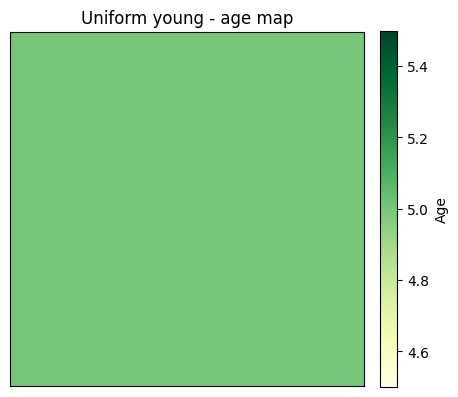

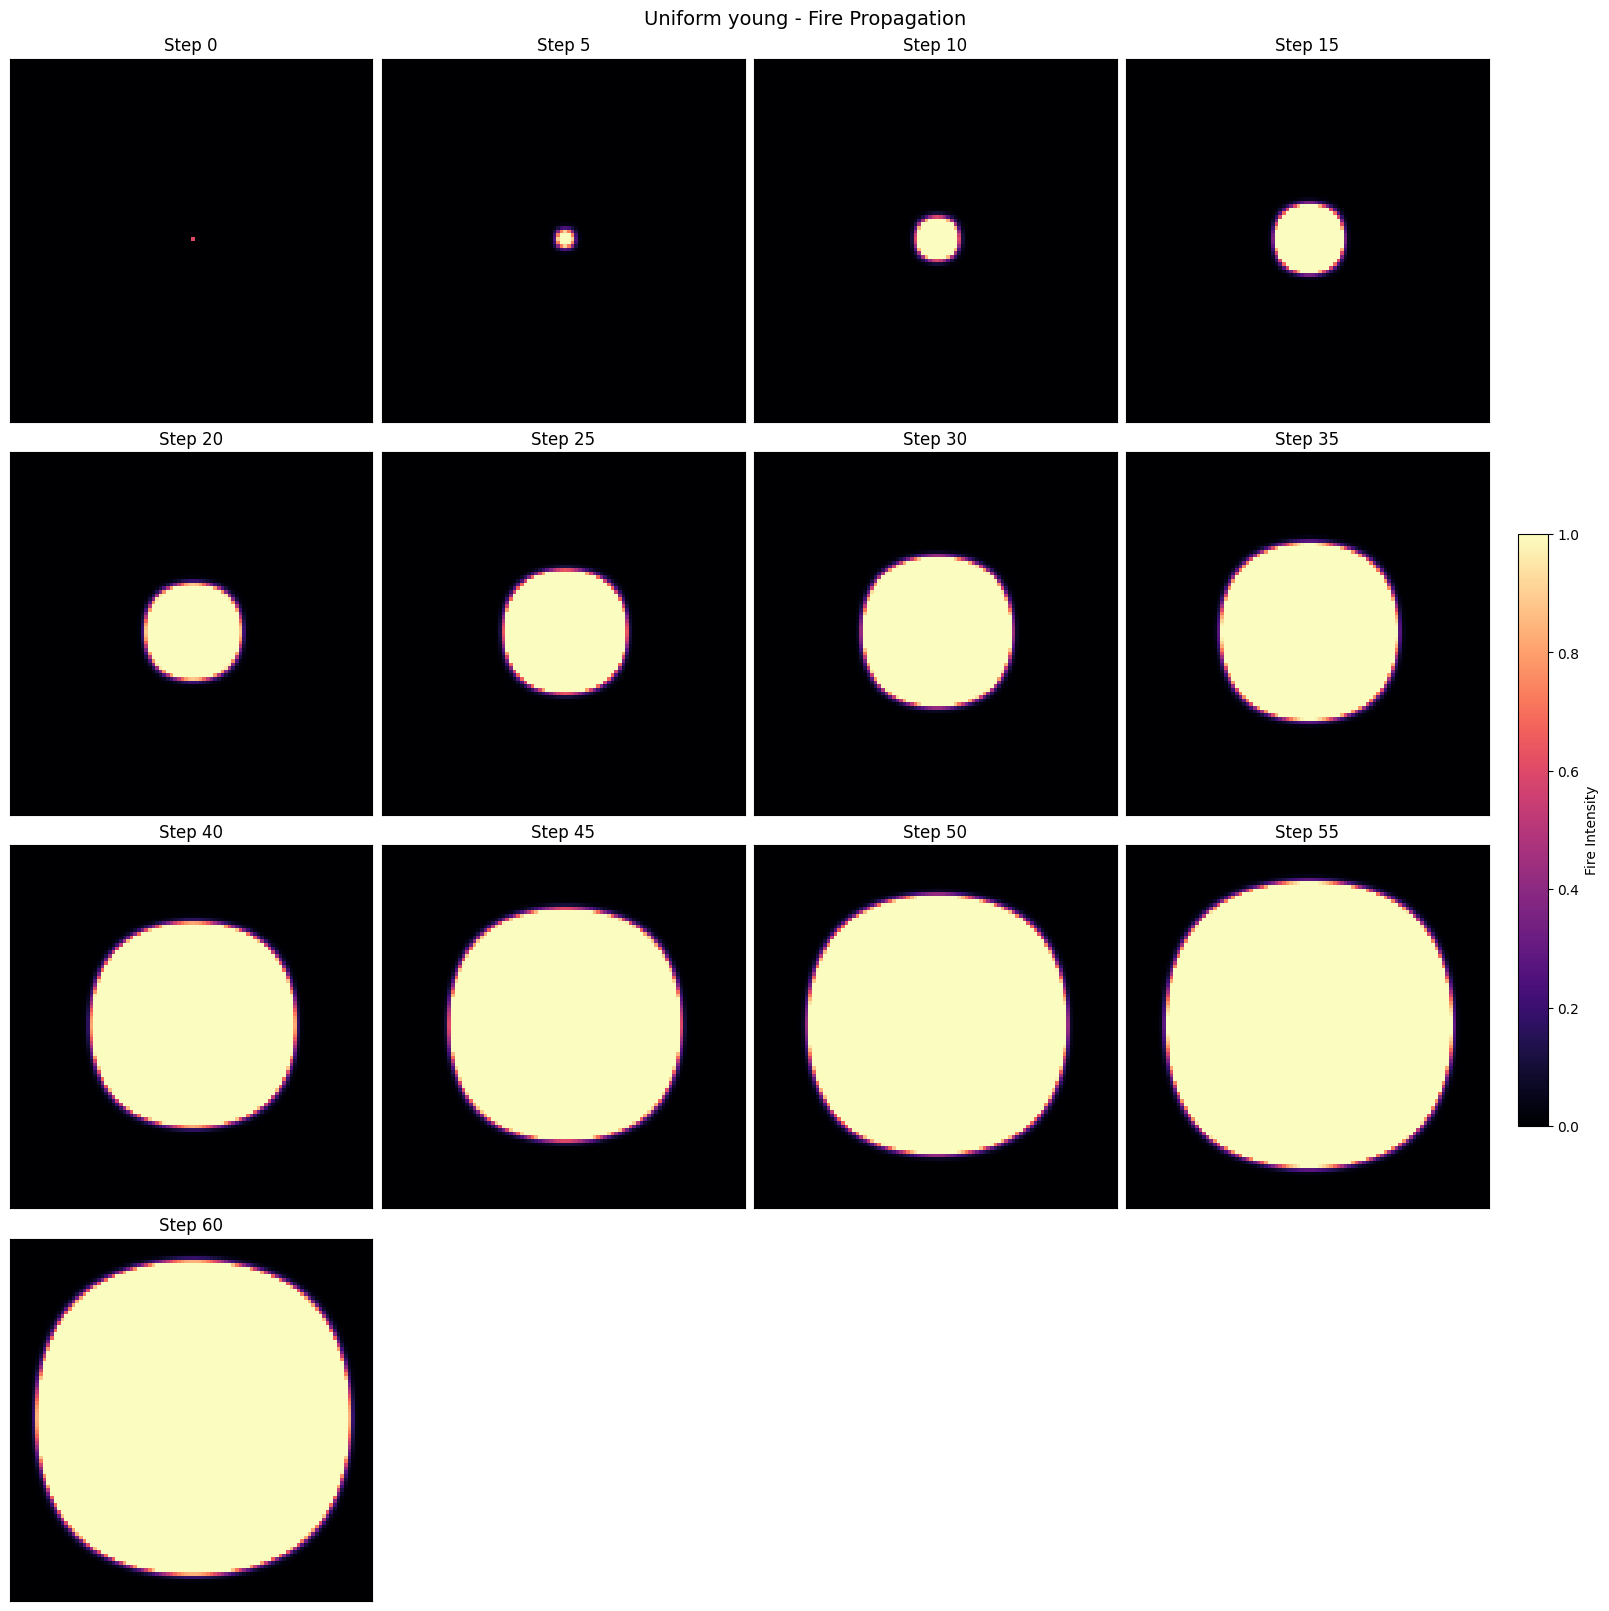

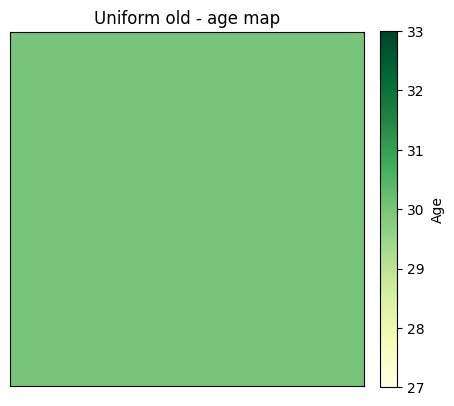

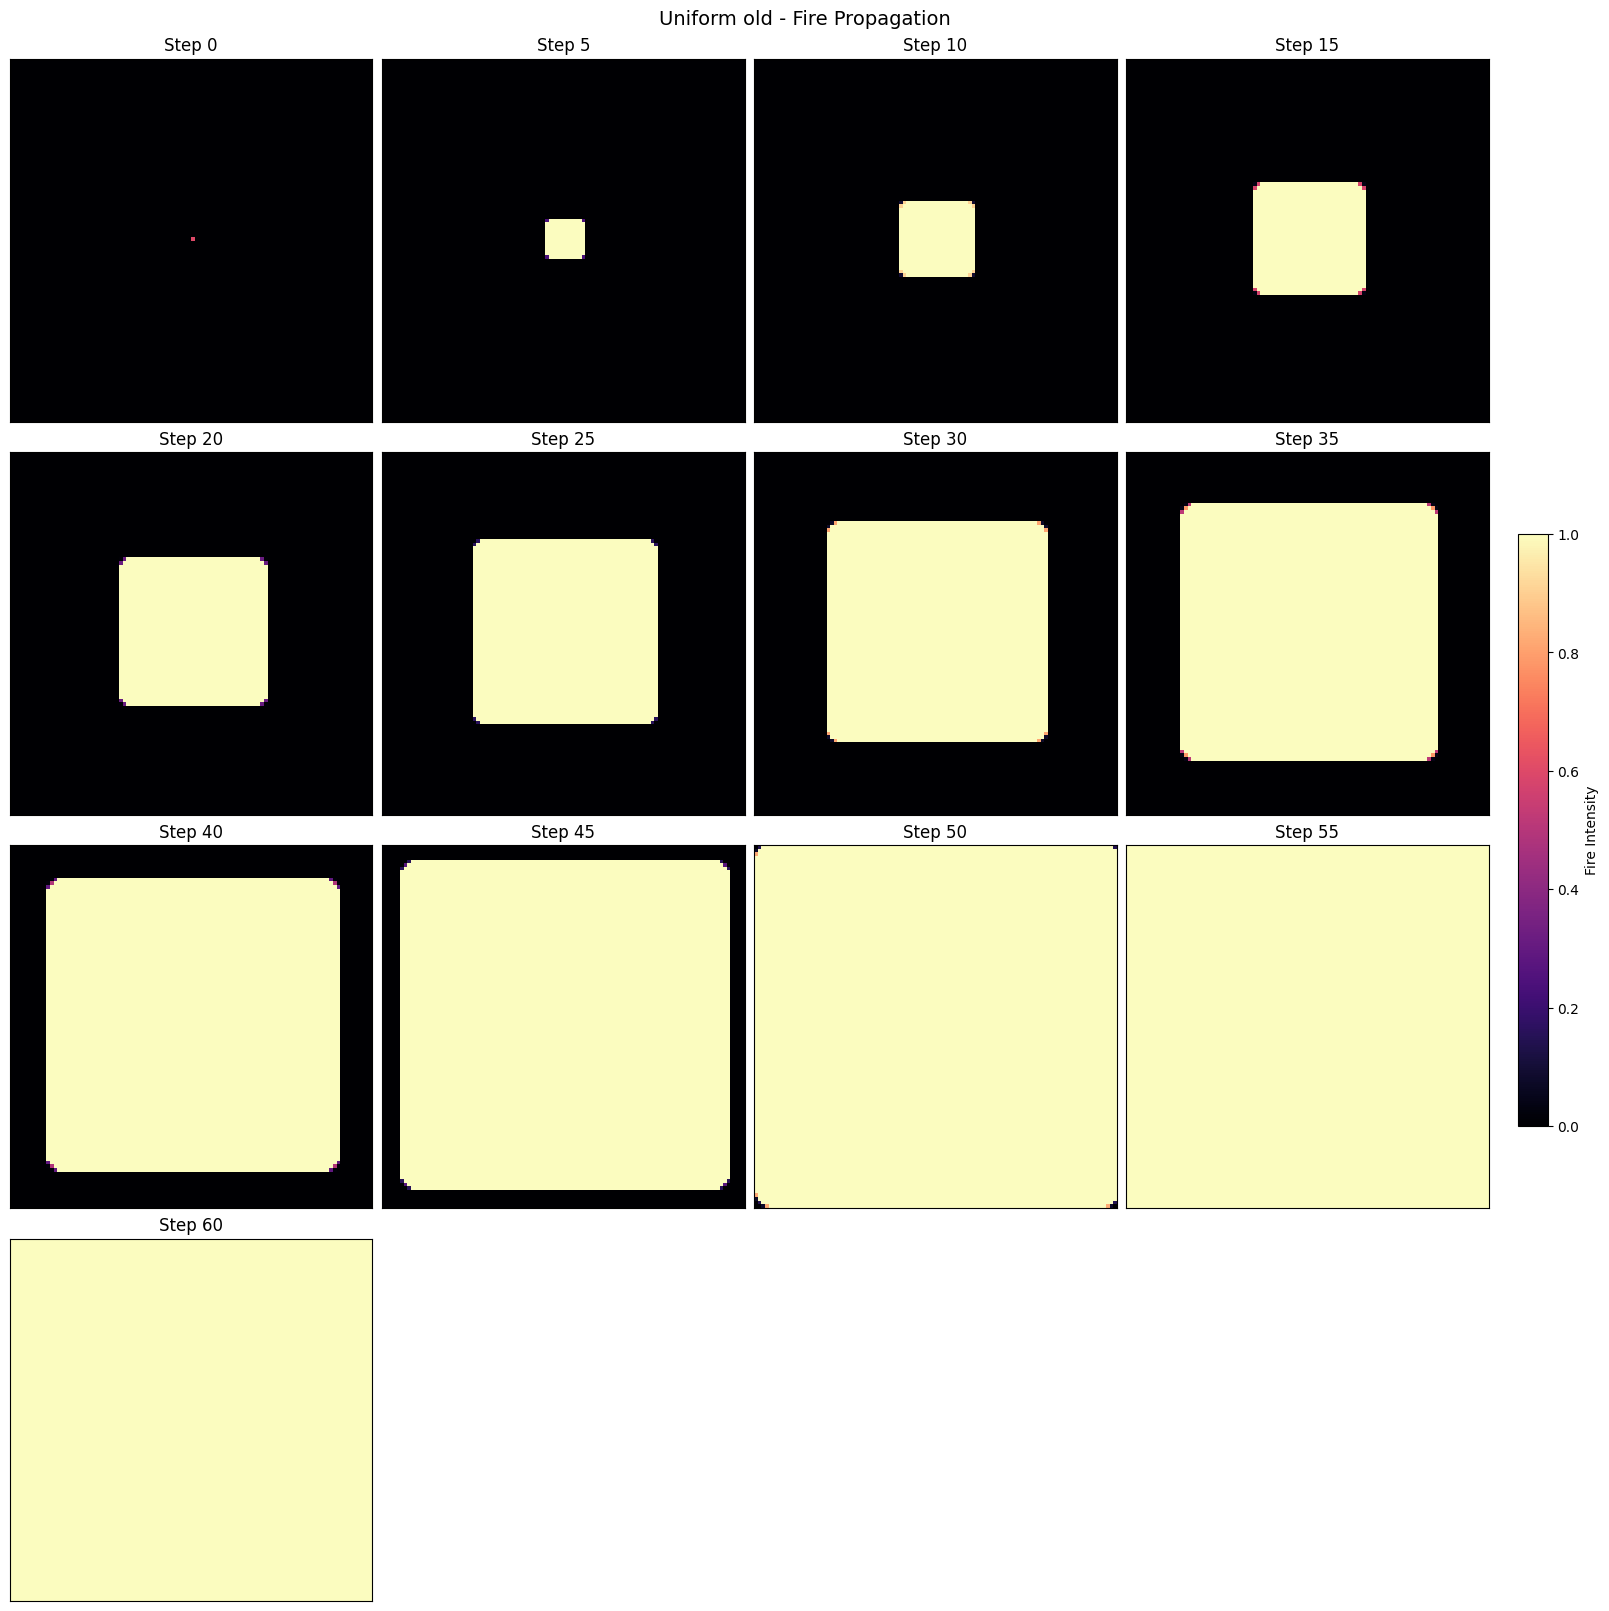

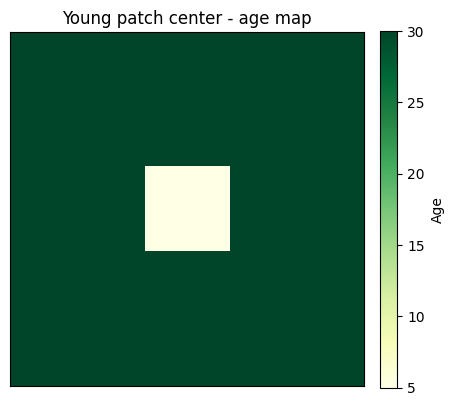

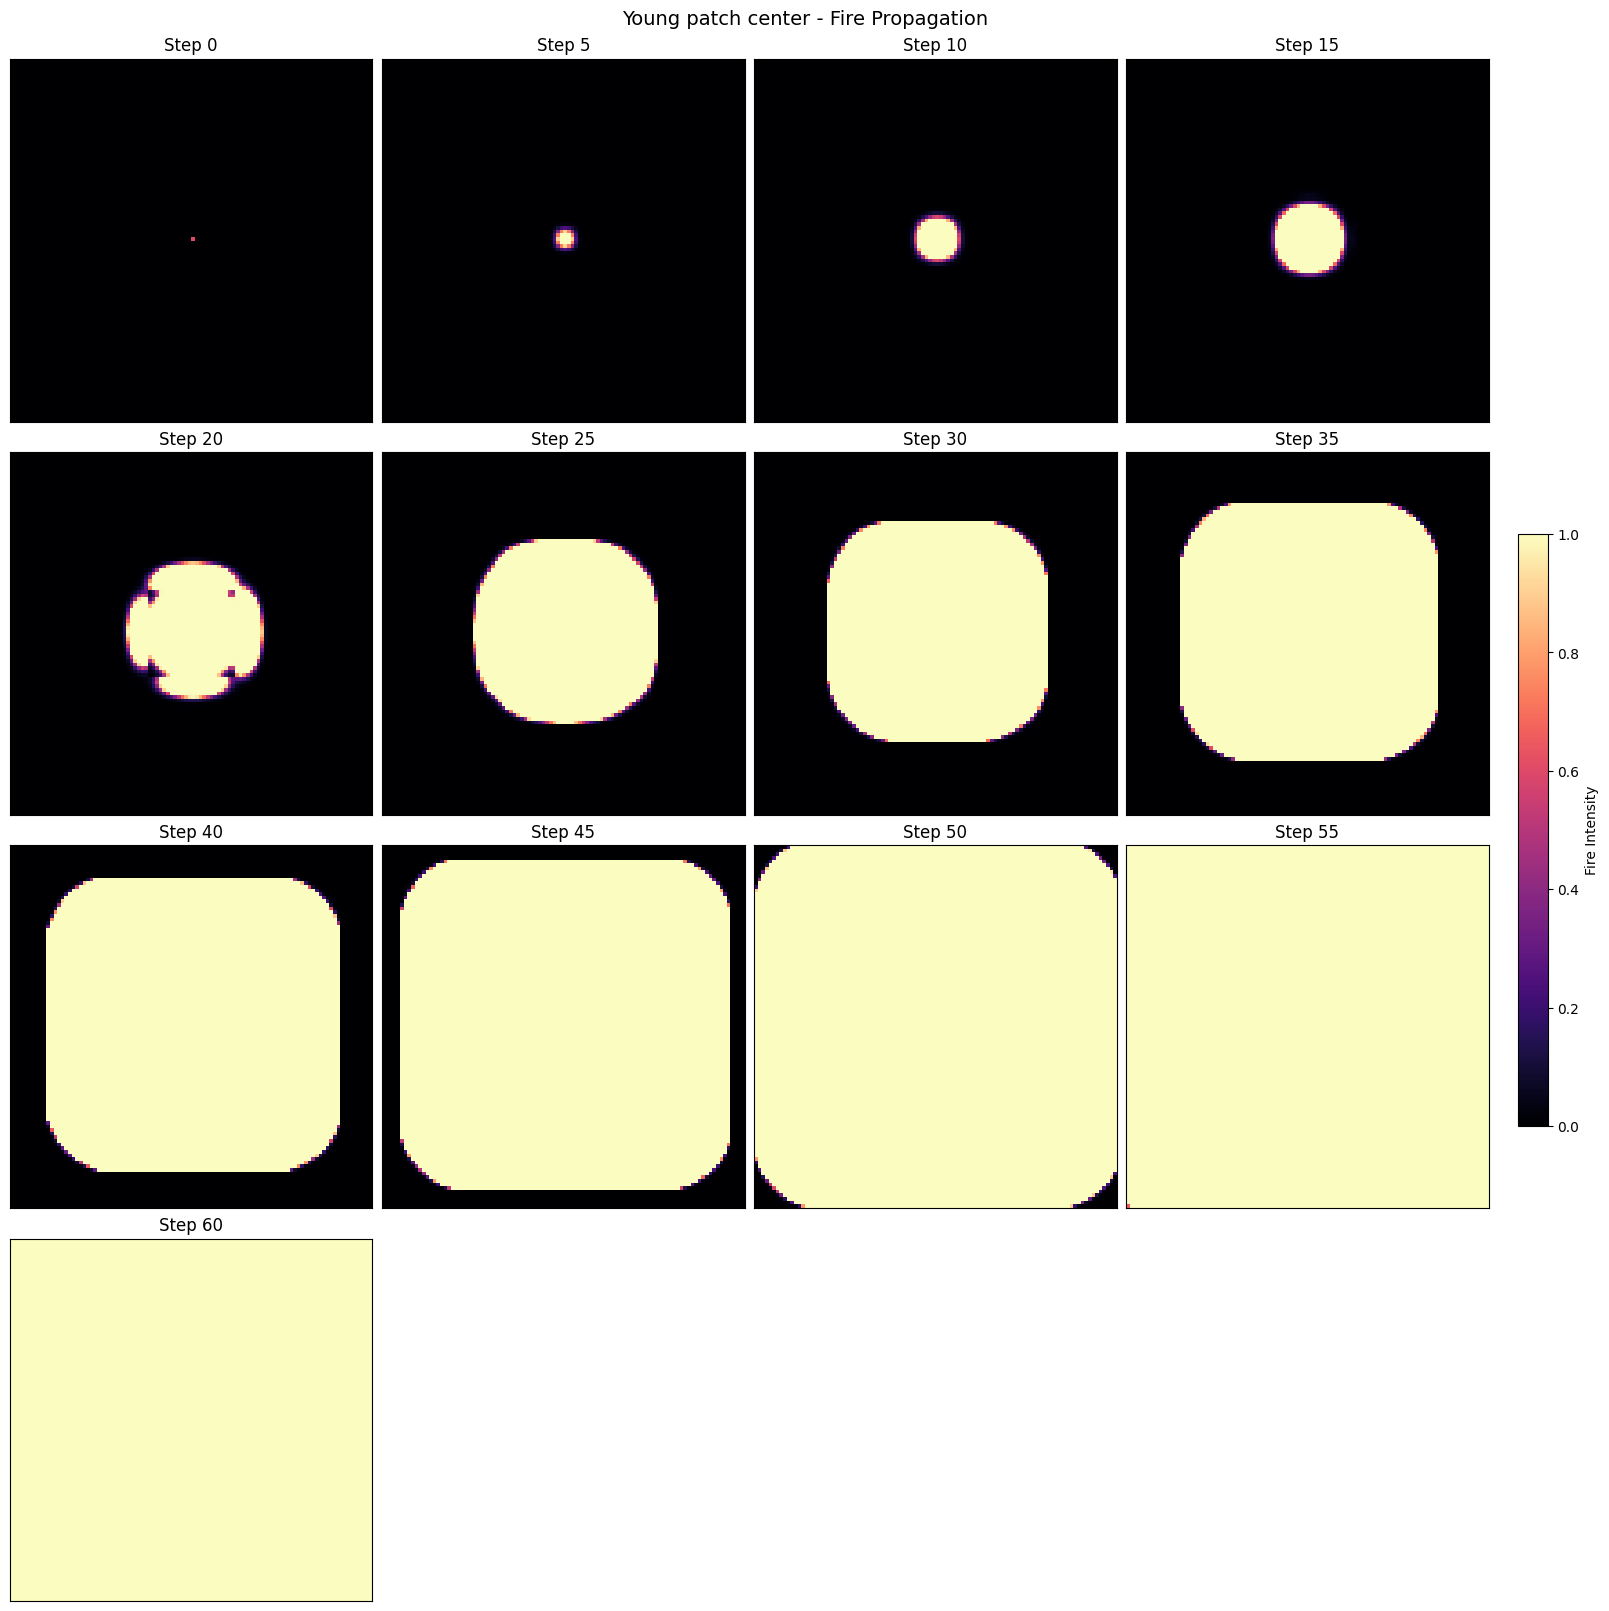

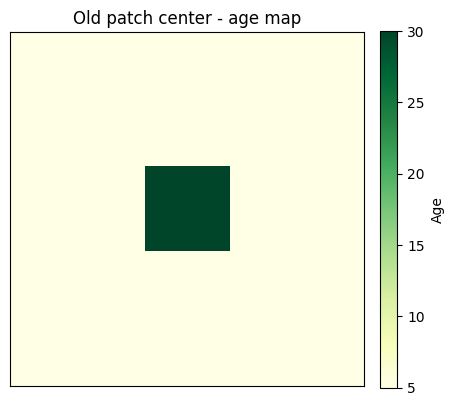

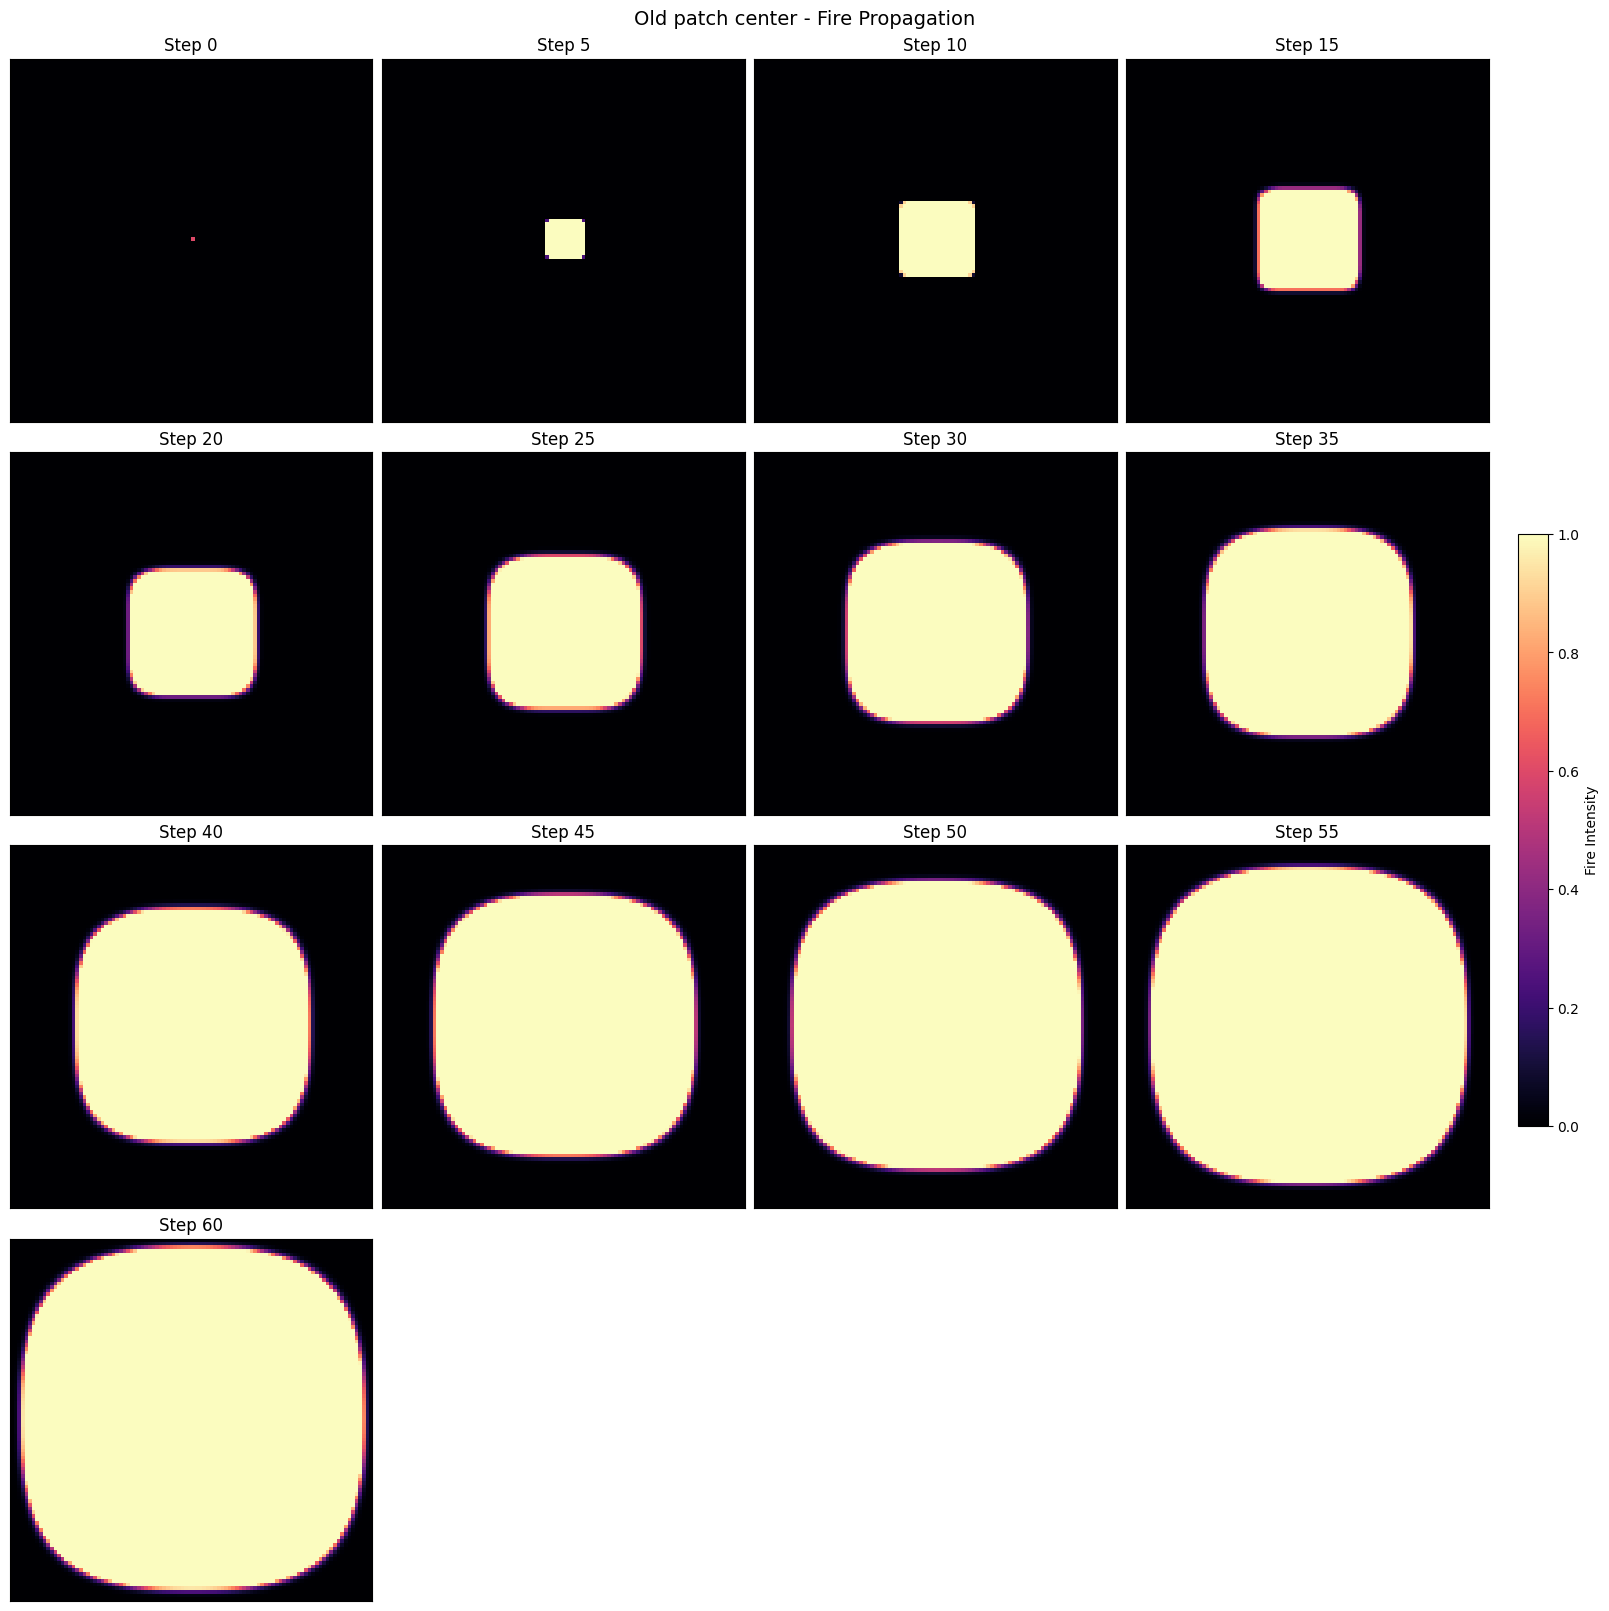

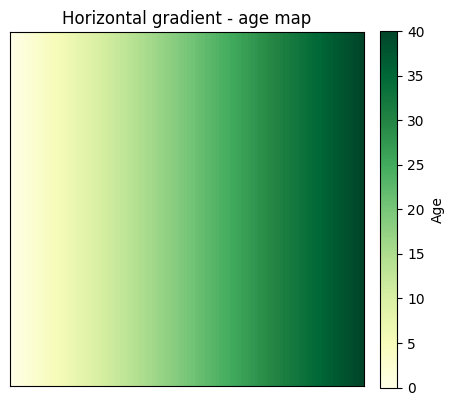

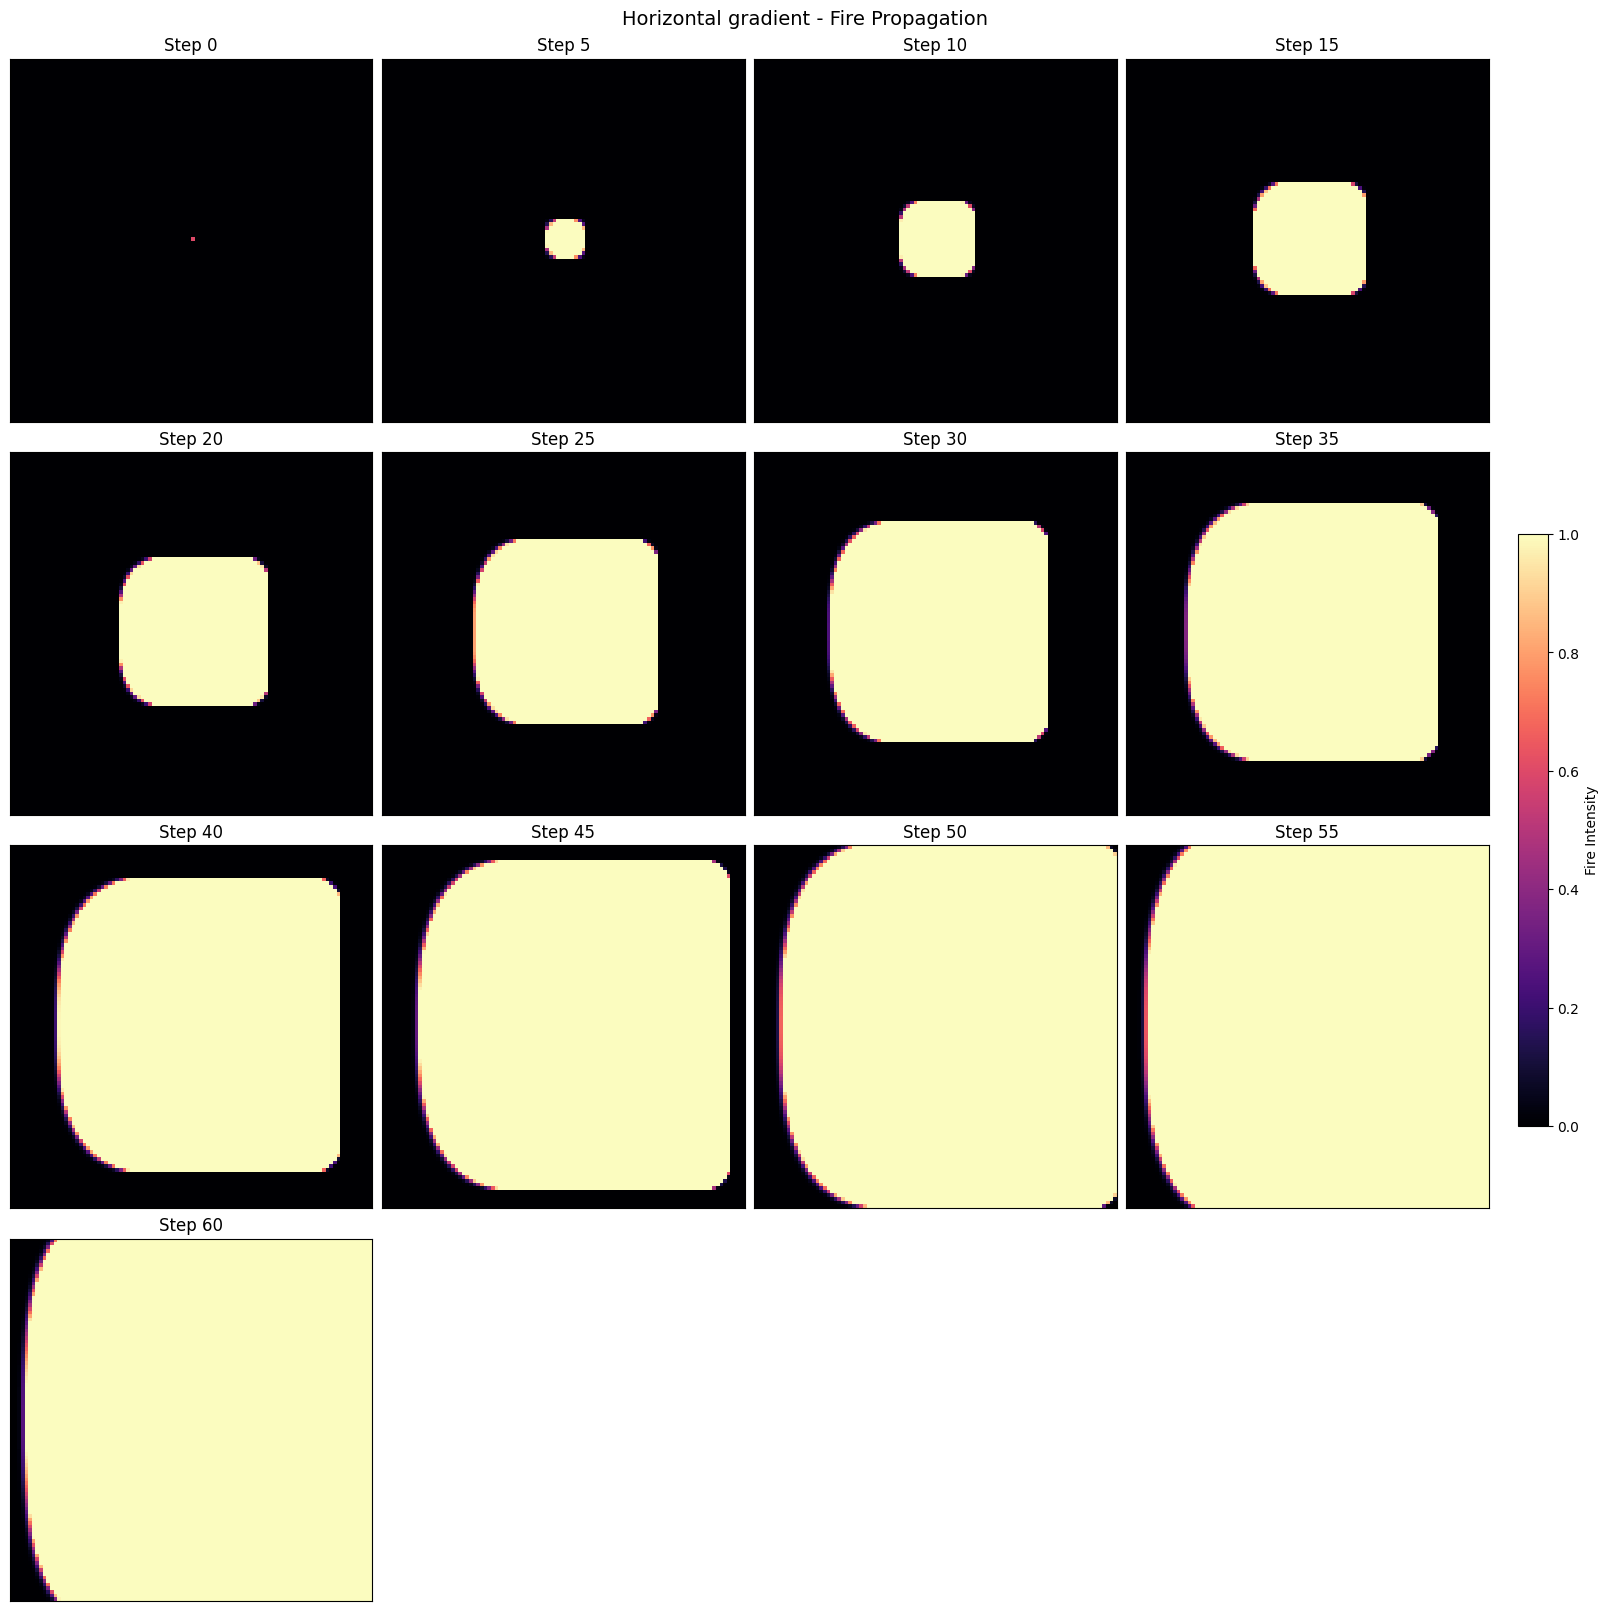

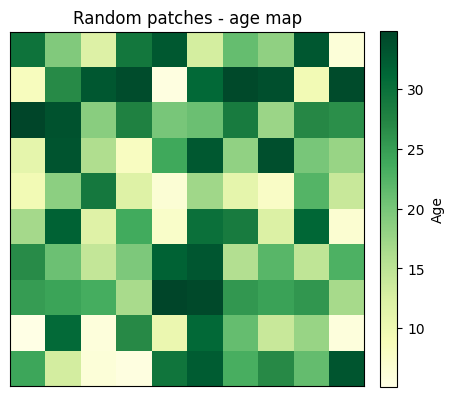

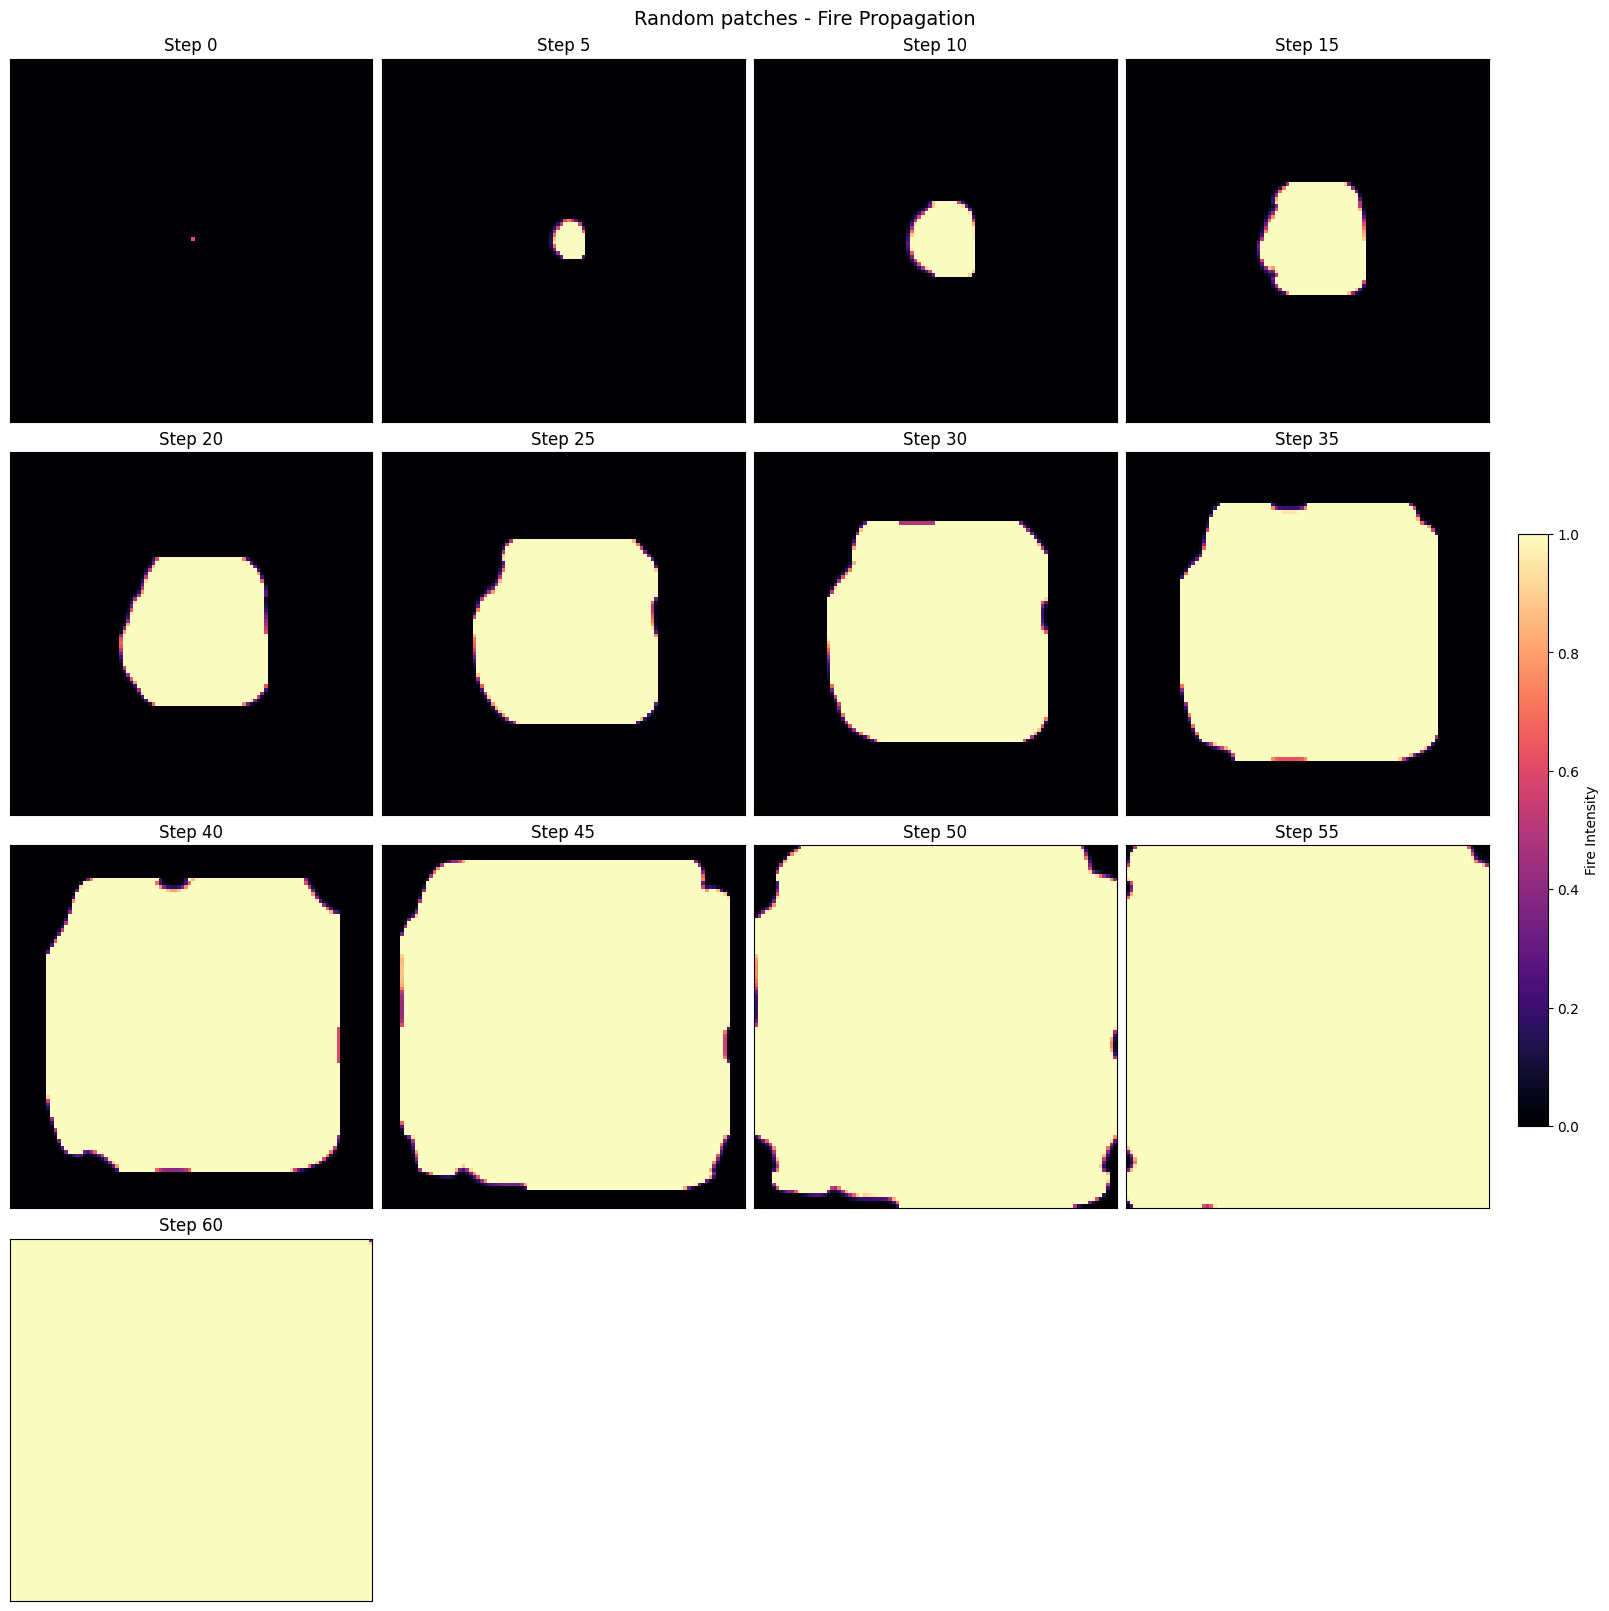

In [14]:
for name, age_grid in age_configs.items():
    plot_age_and_fire(
        name,
        age_grid,
        steps=60,
        display_every=5,
        t_max=30.0,
        p_max=1.0,
        alpha_age=1.0,
    )

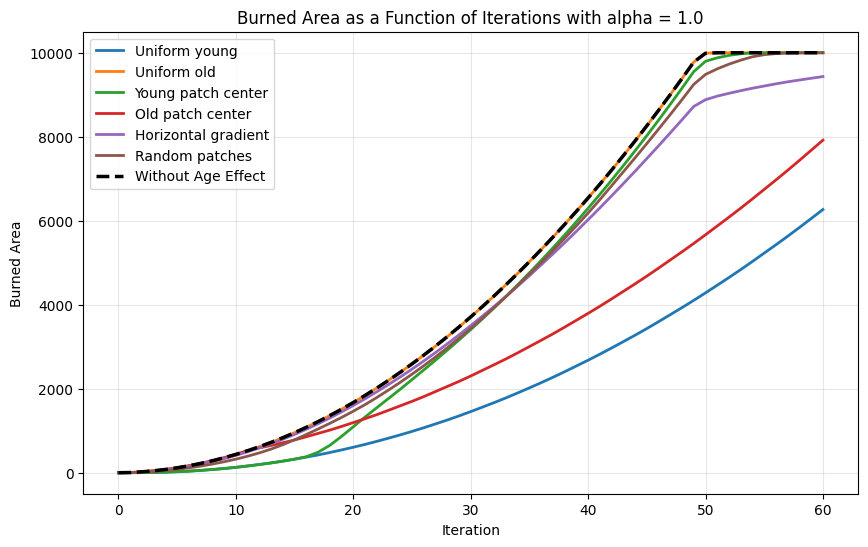

In [17]:
#  Burned area

def burned_area(state_grid: np.ndarray) -> float:
    """
    Burned area 'fractional' :
    sum of intensities on the grid.
    If each cell has area 1, this corresponds to the total burned area.
    """
    return np.sum(state_grid)



def run_burned_area_curve(
    age_grid,
    use_age=True,
    steps=60,
    t_max=30.0,
    p_max=1.0,
    alpha_age=1.0,
):
    """
    Return the burned area at each iteration. If use_age=False, we neutralize the effect of age.
    """
    if use_age:
        effective_age_grid = age_grid.copy()
        effective_t_max = t_max
        effective_p_max = p_max
        effective_alpha_age = alpha_age
    else:
        effective_age_grid = 1000.0 * np.ones_like(age_grid)
        effective_t_max = 1.0
        effective_p_max = 1.0
        effective_alpha_age = 1.0

    CA = CellularAutomaton_modfied(
        grid_height=N,
        grid_width=N,
        wind_grid=wind,
        height_grid=heights,
        age_grid=effective_age_grid,
        phi=height_update,
        t_max=effective_t_max,
        p_max=effective_p_max,
        alpha_age=effective_alpha_age,
    )

    CA.initialize_ignition(start_point, start_state)

    areas = [burned_area(CA.get_state())]

    for _ in range(steps):
        CA.evolve()
        areas.append(burned_area(CA.get_state()))

    return np.arange(steps + 1), np.array(areas)


# Plot of burned area as a function of iterations for each age configuration
plt.figure(figsize=(10, 6))

for name, age_grid in age_configs.items():
    t, area = run_burned_area_curve(
        age_grid,
        use_age=True,
        steps=steps,
        t_max=30.0,
        p_max=1.0,
        alpha_age=1.0,
    )
    plt.plot(t, area, linewidth=2, label=name)

reference_age = next(iter(age_configs.values()))
t_ref, area_ref = run_burned_area_curve(
    reference_age,
    use_age=False,
    steps=steps,
)
plt.plot(
    t_ref,
    area_ref,
    "k--",
    linewidth=2.5,
    label="Without Age Effect"
)

plt.xlabel("Iteration")
plt.ylabel("Burned Area")
plt.title("Burned Area as a Function of Iterations with alpha = 1.0")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()